In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# summarising useful metrics for exploring dataframes

def df_summary(df):
    return pd.DataFrame({
        'dtype': df.dtypes,
        'null_count': df.isna().sum(),
        'null_pct': (df.isna().mean() * 100).round(2),
        'unique_values': df.nunique(),
        'min': df.min(numeric_only=False),
        'max': df.max(numeric_only=False),
    })


In [3]:
import pickle

with open("../data/raw/european_comps_data.pkl", "rb") as f:
    european_comps_data = pickle.load(f)

with open("../data/raw/european_leagues_data.pkl", "rb") as f:
    leagues_data = pickle.load(f)

# Exploratory Data Analysis and Data Wrangling

In this notebook we will explore the data scraped in the data_scraping.ipynb notebook by first checking their consistency (null values, duplicates, outliers) as potential indicators of data quality issues.

We will then produce new data structures to support the statistical analysis, which is the main goal of the project. The analysis will conduct a study of the disciplinary behavior of different teams — whether and how it differs between national leagues and international competitions — and whether disciplinary outcomes by referees differ systematically across teams. As disciplinary measures, we will focus mainly on yellow and red cards, alongside the number of fouls committed and received, and any other metrics the analysis may suggest.

In [4]:
leagues_data.keys()

dict_keys(['Serie_A', 'Premier_League', 'La_Liga', 'Bundesliga', 'Ligue_1'])

## National Leagues Data Dictionary

- `Date`: `str` - Match Date (dd/mm/yy)
- `HomeTeam`: `str` - Home Team
- `AwayTeam`: `str` - Away Team
- `FTHG` - `float64` - Results - Full Time Home Team Goals
- `FTAG` - `float64`- Results - Full Time Away Team Goals
- `FTR` - `str` - Results - Full Time Result (H=Home Win, D=Draw, A=Away Win)
- `HTHG` - `float64` - Results - Half Time Home Team Goals
- `HTAG` - `float64` - Results - Half Time Away Team Goals
- `HTR` - `str` - Results - Half Time Result (H=Home Win, D=Draw, A=Away Win)
- `HF` - `float64` - Discipline - Home Team Fouls Committed
- `AF` - `float64` - Discipline - Away Team Fouls Committed
- `HY` - `float64` - Discipline - Home Team Yellow Cards
- `AY` - `float64` - Discipline - Away Team Yellow Cards
- `HR` - `float64` - Discipline - Home Team Red Cards
- `AR` - `float64` - Discipline - Away Team Red Cards
- `HS` - `float64` - Attack/Defence - Home Team Shots
- `AS` - `float64` - Attack/Defence - Away Team Shots
- `HST` - `float64` - Attack/Defence - Home Team Shots on Target
- `AST` - `float64` - Attack/Defence - Away Team Shots on Target
- `HC` - `float64` - Attack/Defence - Home Team Corners
- `AC` - `float64` - Attack/Defence - Away Team Corners
- `season` - `str` - Season (yyyy)

### Serie A data

#### Null Values

In [5]:
df_Serie_A = leagues_data['Serie_A']
df_Serie_A.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
0,23/08/2025,Genoa,Lecce,0.0,0.0,D,0.0,0.0,D,16.0,...,3.0,0.0,0.0,5.0,7.0,2.0,0.0,3.0,7.0,2526
1,23/08/2025,Sassuolo,Napoli,0.0,2.0,A,0.0,1.0,A,17.0,...,1.0,1.0,0.0,7.0,13.0,2.0,4.0,1.0,2.0,2526
2,23/08/2025,Milan,Cremonese,1.0,2.0,A,1.0,1.0,D,10.0,...,4.0,0.0,0.0,24.0,4.0,6.0,3.0,9.0,2.0,2526
3,23/08/2025,Roma,Bologna,1.0,0.0,H,0.0,0.0,D,15.0,...,1.0,0.0,0.0,14.0,10.0,4.0,2.0,2.0,4.0,2526
4,24/08/2025,Cagliari,Fiorentina,1.0,1.0,D,0.0,0.0,D,18.0,...,2.0,0.0,0.0,14.0,4.0,6.0,1.0,3.0,2.0,2526


In [6]:
df_Serie_A.isna().sum()

Date        5
HomeTeam    5
AwayTeam    5
FTHG        5
FTAG        5
FTR         5
HTHG        7
HTAG        7
HTR         7
HF          6
AF          6
HY          7
AY          6
HR          6
AR          6
HS          6
AS          6
HST         6
AST         6
HC          6
AC          6
season      0
dtype: int64

In [7]:
df_Serie_A[df_Serie_A['season']=='2526']['HomeTeam'].nunique()

20

In [8]:
df_Serie_A['season'].value_counts().sort_index()

season
1112    380
1213    383
1314    380
1415    381
1516    381
1617    380
1718    380
1819    380
1920    380
2021    380
2122    380
2223    380
2324    380
2425    380
2526    300
Name: count, dtype: int64

In [9]:
df_Serie_A[df_Serie_A['HY'].isna()]

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
4100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1516
4348,02/03/15,Roma,Juventus,1.0,1.0,D,0.0,0.0,D,11.0,...,5.0,1.0,0.0,8.0,10.0,3.0,1.0,1.0,5.0,1415
4481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1415
4896,23/09/12,Cagliari,Roma,0.0,3.0,A,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1213
5242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1213
5243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1213
5244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1213


After reviewing the raw data directly downloaded from the website, is safe to drop all rows containing `NaN`s. We will lose data from a single match only on seasons 2012/13 and 2014/15. It means not considering about 0.3% of the data for that seasons. 

In [10]:
discipline_cols = ['HF', 'AF', 'HY', 'AY', 'HR', 'AR']
df_Serie_A = df_Serie_A.dropna(subset=discipline_cols).copy()

In [11]:
df_Serie_A['season'].value_counts().reset_index().sort_values(by='season').reset_index(drop = True)

,season,count
0,1112,380
1,1213,379
2,1314,380
3,1415,379
4,1516,380
5,1617,380
6,1718,380
7,1819,380
8,1920,380
9,2021,380


After removing Serie A null values, we just lost two games in seasons 2012/13 and 2014/15 as we are missing the Home Yellow cards information. 

#### Duplicated Values

In [12]:
df_Serie_A.duplicated().sum()

np.int64(0)

In [13]:
df_Serie_A[df_Serie_A.duplicated()]

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season


No duplicated values.

### Premier League Data

In [14]:
df_Premier_League = leagues_data['Premier_League']

#### Null Values

In [15]:
df_Premier_League['season'].value_counts()

season
1415    381
2425    380
2324    380
2223    380
2122    380
2021    380
1920    380
1819    380
1718    380
1617    380
1516    380
1314    380
1213    380
1112    380
2526    309
Name: count, dtype: int64

In [16]:
df_Premier_League.isna().sum()

Date        1
HomeTeam    1
AwayTeam    1
FTHG        1
FTAG        1
FTR         1
HTHG        1
HTAG        1
HTR         1
HF          1
AF          1
HY          1
AY          1
HR          1
AR          1
HS          1
AS          1
HST         1
AST         1
HC          1
AC          1
season      0
dtype: int64

In [17]:
df_Premier_League[df_Premier_League['HY'].isna()]

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
4489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1415


We can safely drop the above row from the dataframe.

In [18]:
discipline_cols = ['HF', 'AF', 'HY', 'AY', 'HR', 'AR']
df_Premier_League = df_Premier_League.dropna(subset=discipline_cols).copy()

#### Duplicated Values

In [19]:
df_Premier_League.duplicated().sum()

np.int64(0)

No duplicated value to take care of.

### La Liga Data

In [20]:
df_La_Liga = leagues_data['La_Liga']

#### Null Values

In [21]:
df_La_Liga.isna().sum()

Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
HF          0
AF          0
HY          0
AY          0
HR          0
AR          0
HS          0
AS          0
HST         0
AST         0
HC          0
AC          0
season      0
dtype: int64

In [22]:
df_La_Liga['season'].value_counts()

season
2425    380
2324    380
2223    380
2122    380
2021    380
1920    380
1819    380
1718    380
1617    380
1516    380
1415    380
1314    380
1213    380
1112    380
2526    290
Name: count, dtype: int64

#### Duplicated Values

In [23]:
df_La_Liga.duplicated().sum()

np.int64(0)

No duplicated values in this data frame as well.

### Bundesliga Data

In [24]:
df_Bundesliga = leagues_data['Bundesliga']

#### Null Values

In [25]:
df_Bundesliga['season'].value_counts()

season
2425    306
2324    306
2223    306
2122    306
2021    306
1920    306
1819    306
1718    306
1617    306
1516    306
1415    306
1314    306
1213    306
1112    306
2526    243
Name: count, dtype: int64

In [26]:
df_Bundesliga.isna().sum()

Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        1
HTAG        1
HTR         1
HF          1
AF          1
HY          1
AY          1
HR          1
AR          1
HS          1
AS          1
HST         1
AST         1
HC          1
AC          1
season      0
dtype: int64

In [27]:
df_Bundesliga[df_Bundesliga['HY'].isna()]

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
364,14/12/2024,Union Berlin,Bochum,0,2,A,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2425


Dropping just one row for season means losing, again, about 0.3% of the data for just that season. It won't affect the overall analysis.

In [28]:
df_Bundesliga[df_Bundesliga['season'] == '2425']['HomeTeam'].nunique()

18

In [29]:
18*17

306

In [30]:
1/306

0.0032679738562091504

In [31]:
discipline_cols = ['HF', 'AF', 'HY', 'AY', 'HR', 'AR']
df_Bundesliga = df_Bundesliga.dropna(subset=discipline_cols).copy()

In [32]:
df_Bundesliga['season'].value_counts().reset_index().sort_values(by ='season').reset_index(drop = True)

,season,count
0,1112,306
1,1213,306
2,1314,306
3,1415,306
4,1516,306
5,1617,306
6,1718,306
7,1819,306
8,1920,306
9,2021,306


#### Duplicated Values

In [33]:
df_Bundesliga.duplicated().sum()

np.int64(0)

### Ligue 1 Data

In [34]:
df_Ligue_1 = leagues_data['Ligue_1']

#### Null Values

In [35]:
df_Ligue_1.isna().sum()

Date        2
HomeTeam    2
AwayTeam    2
FTHG        2
FTAG        2
FTR         2
HTHG        3
HTAG        3
HTR         3
HF          5
AF          5
HY          3
AY          3
HR          3
AR          3
HS          3
AS          3
HST         3
AST         3
HC          3
AC          3
season      0
dtype: int64

In [36]:
df_Ligue_1[df_Ligue_1['HF'].isna()]

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
3358,16/04/17,Bastia,Lyon,0.0,3.0,A,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1617
3793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1516
4554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1314
4993,18/09/11,Lyon,Marseille,2.0,0.0,H,2.0,0.0,H,NaN,...,3.0,0.0,0.0,10.0,6.0,5.0,3.0,3.0,5.0,1112
5106,17/12/11,Caen,Nancy,1.0,2.0,A,0.0,1.0,A,NaN,...,5.0,0.0,0.0,9.0,9.0,1.0,3.0,8.0,1.0,1112


As for the match Bastia vs Lyon, this match was officially abandoned after an attack on players by fans and was never replayed. It is not a data quality issue but the match genuinely has no statistics.

Lyon vs Marseille and Caen vs Nancy in 2011/12 have HF=NaN, meaning fouls data is missing. Since fouls are our key normalization variable for the discipline analysis, losing it for these matches is more significant than losing other stats. 

In [37]:
df_Ligue_1['season'].value_counts().reset_index().sort_values(by = 'season').reset_index(drop=True)

,season,count
0,1112,380
1,1213,380
2,1314,381
3,1415,380
4,1516,381
5,1617,380
6,1718,380
7,1819,380
8,1920,279
9,2021,380


The number of recorded matches matches the [Ligue 1 format](https://en.wikipedia.org/wiki/Ligue_1#Format) in terms of number of teams competing each season. Ligue 1 reduced from 20 to 18 teams starting 2023/24, explaining the drop in number of matches.

Dropping all rows without information about `HF` (number of fouls committed by home team) will not affect the overall analysis for Ligue 1. Unlikely the other leagues we are analysing, Ligue 1 [cancelled part of 2019/20 season due to COVID outbreake](https://en.wikipedia.org/wiki/2019%E2%80%9320_Ligue_1) which explain why only 279 matches were played that season.

In [38]:
discipline_cols = ['HF', 'AF', 'HY', 'AY', 'HR', 'AR']

df_Ligue_1 = df_Ligue_1.dropna(subset=discipline_cols).copy()

In [39]:
df_Ligue_1['season'].value_counts().reset_index().sort_values(by = 'season').reset_index(drop=True)

,season,count
0,1112,378
1,1213,380
2,1314,380
3,1415,380
4,1516,380
5,1617,379
6,1718,380
7,1819,380
8,1920,279
9,2021,380


#### Duplicated Values.

In [40]:
df_Ligue_1.duplicated().sum()

np.int64(0)

### Rebuilding the leagues dictionary with cleaned data

After loading the raw data, each league dataframe was cleaned individually. The original `leagues_data` dictionary still points to the uncleaned data. Before moving to the exploration phase, we rebuild it to reflect the cleaned state — this ensures any downstream code that references the dictionary directly is working on verified data.

In [41]:
leagues_data = {
    'Serie_A':        df_Serie_A,
    'Premier_League': df_Premier_League,
    'La_Liga':        df_La_Liga,
    'Bundesliga':     df_Bundesliga,
    'Ligue_1':        df_Ligue_1,
}

## Exploring National Leagues datasets

We cleaned the major leagues dataset and now we want to check if data looks "healthy", meaning they don't show any evident outlier or unespected distribution.

In [42]:
for league in leagues_data.keys():
    print(f"{league} dataset has {leagues_data[league].shape[0]} rows")

Serie_A dataset has 5618 rows
Premier_League dataset has 5629 rows
La_Liga dataset has 5610 rows
Bundesliga dataset has 4526 rows
Ligue_1 dataset has 5310 rows


In [43]:
df_summary(leagues_data['Serie_A'])

,dtype,null_count,null_pct,unique_values,min,max
Date,str,0,0.00,1636,01/02/12,31/10/2024
HomeTeam,str,0,0.00,40,Atalanta,Verona
AwayTeam,str,0,0.00,40,Atalanta,Verona
FTHG,float64,0,0.00,9,0.0,8.0
FTAG,float64,0,0.00,8,0.0,7.0
FTR,str,0,0.00,3,A,H
HTHG,float64,1,0.02,6,0.0,5.0
HTAG,float64,1,0.02,6,0.0,5.0
HTR,str,1,0.02,3,A,H
HF,float64,0,0.00,29,1.0,29.0


Each dataset contains at least 4.5K datapoints, data visualization can help to give a first look at data distribution and hint possible issues.

Let's start with the disciplinary columns and start with a simple visualization: violin plot.

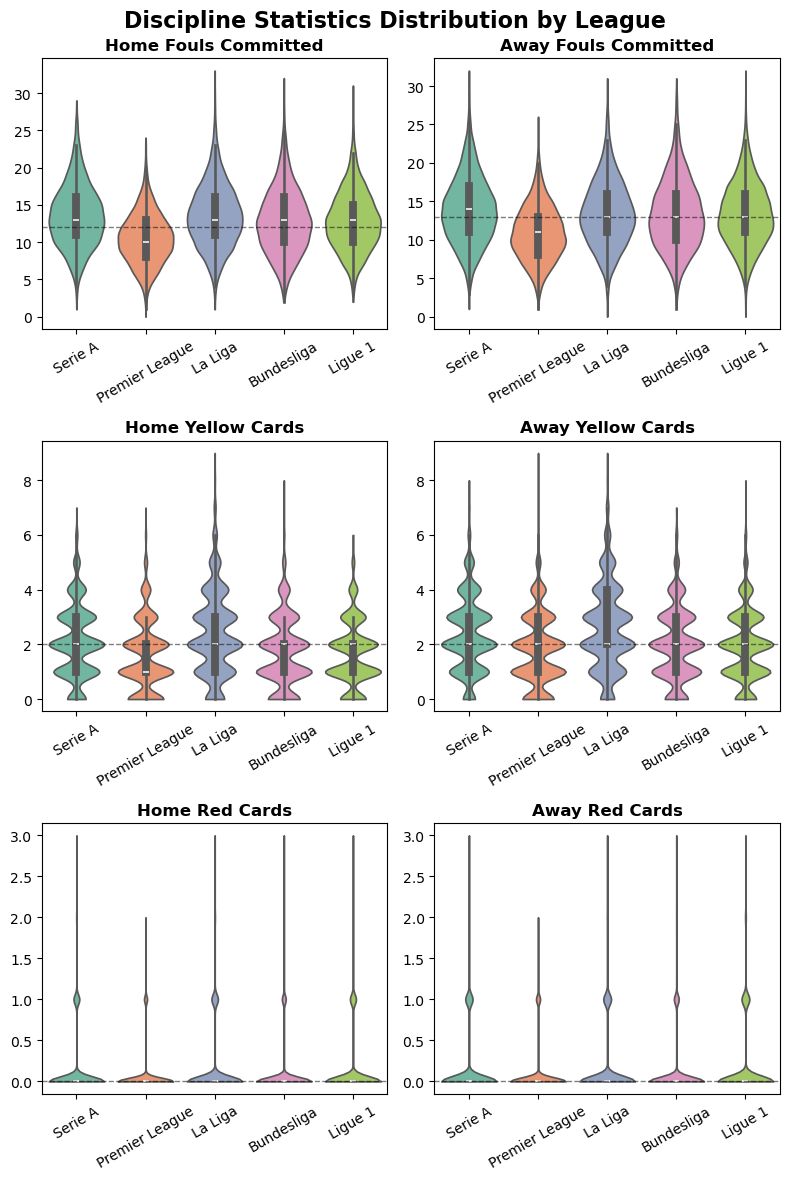

In [44]:
discipline_cols = ['HF', 'AF', 'HY', 'AY', 'HR', 'AR']

col_labels = {
    'HF': 'Home Fouls Committed',
    'AF': 'Away Fouls Committed',
    'HY': 'Home Yellow Cards',
    'AY': 'Away Yellow Cards',
    'HR': 'Home Red Cards',
    'AR': 'Away Red Cards',
}

league_dfs = {
    'Serie A':        df_Serie_A,
    'Premier League': df_Premier_League,
    'La Liga':        df_La_Liga,
    'Bundesliga':     df_Bundesliga,
    'Ligue 1':        df_Ligue_1,
}

plot_data = pd.concat(
    [df[discipline_cols].assign(League=name) for name, df in league_dfs.items()],
    ignore_index=True
)

fig, axes = plt.subplots(3, 2, figsize=(8, 12))
axes = axes.flatten()

for i, col in enumerate(discipline_cols):
    sns.violinplot(
        data=plot_data,
        x='League', y=col,
        hue='League',
        ax=axes[i],
        palette='Set2',
        legend=False,
        inner='box',
        cut=0,
    )
    overall_median = plot_data[col].median()
    axes[i].axhline(overall_median, color='black', linestyle='--', linewidth=1.0, alpha=0.5)
    axes[i].set_title(col_labels[col], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Discipline Statistics Distribution by League', fontsize=16, fontweight='bold')
plt.tight_layout()

What works well in this plot:

- The fouls panels are excellent: we can clearly see La Liga and Ligue 1 tend to have more fouls, Premier League fewer.
- The home/away symmetry is visible at a glance: distributions within each league look similar left-right, which is a healthy sanity check.
- Yellow cards show the discrete "steps" in the violin shape, which is actually informative — it reflects the integer nature of the data honestly, while visually suggesting the relationship between fouls committed and cards received.
- The dashed overall median line confirms that median values are consistent within each league. In the Premier League specifically, both fouls and yellow cards are lower, but the away team appears slightly more likely to receive a card — a pattern worth keeping in mind.

What needs to be improved:

- Red cards are almost useless as violins. The distribution is so heavily concentrated at zero that we get a spike with a thin tail — the shape conveys almost no information. This is not a failure of the visualization technique in general, but a mismatch between the tool and the data: violin plots work best for continuous or near-continuous distributions, not for count data dominated by a single value. Red cards need a different approach.

The violin plot is kept for fouls and yellow cards, with red cards moved to a separate chart:

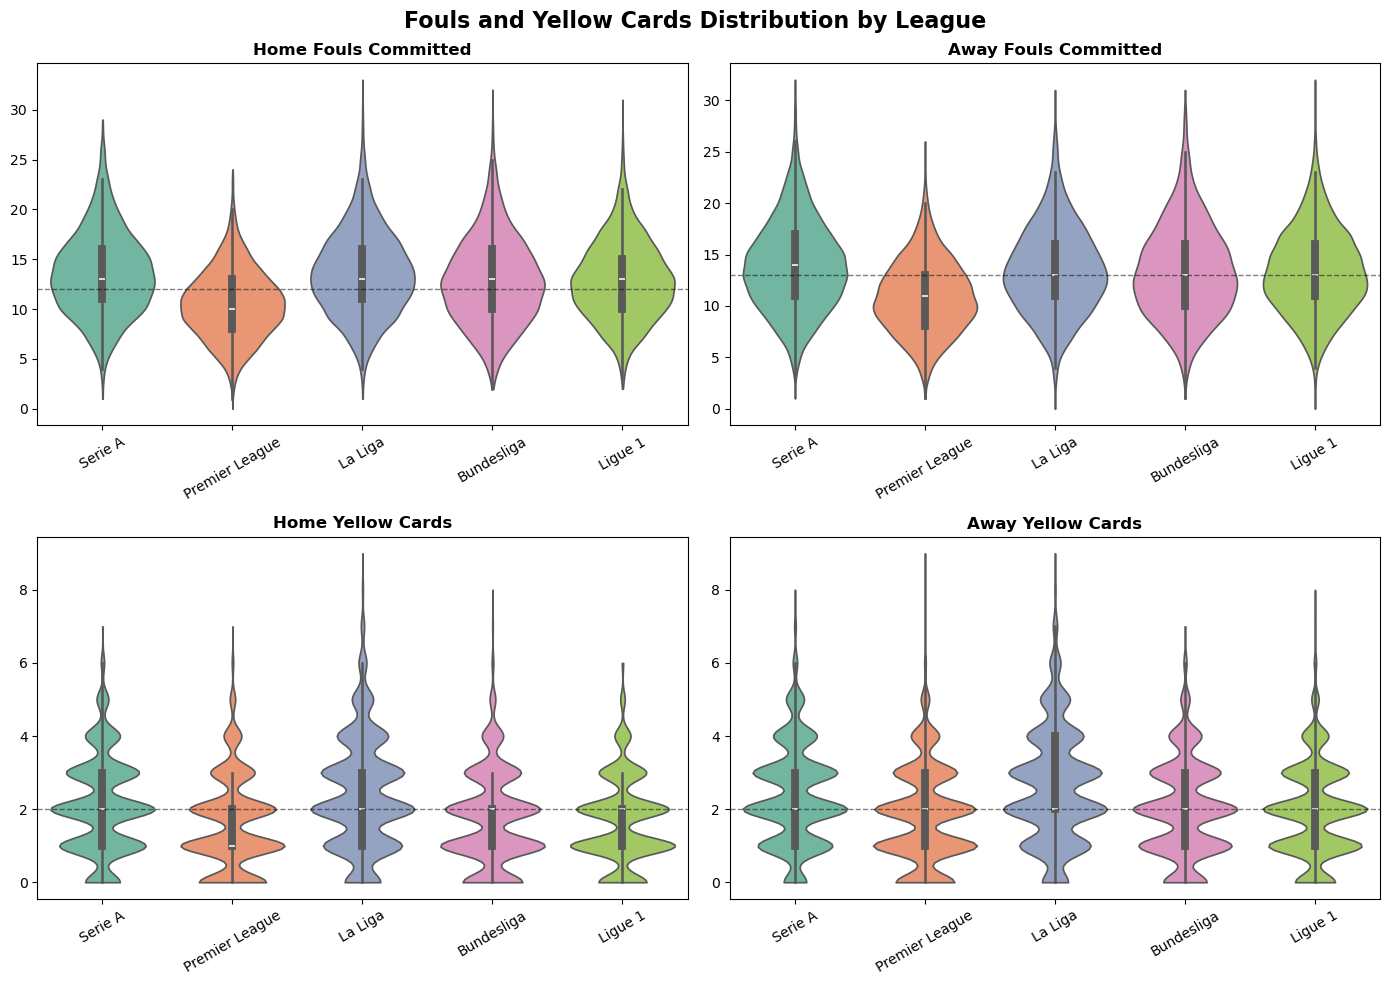

In [45]:
# Redefine for the 4-column violin (red cards handled separately below)
discipline_cols = ['HF', 'AF', 'HY', 'AY']

col_labels = {
    'HF': 'Home Fouls Committed',
    'AF': 'Away Fouls Committed',
    'HY': 'Home Yellow Cards',
    'AY': 'Away Yellow Cards',
}

plot_data = pd.concat(
    [df[discipline_cols].assign(League=name) for name, df in league_dfs.items()],
    ignore_index=True
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(discipline_cols):
    sns.violinplot(
        data=plot_data,
        x='League', y=col,
        hue='League',
        ax=axes[i],
        palette='Set2',
        legend=False,
        inner='box',
        cut=0,
    )
    overall_median = plot_data[col].median()
    axes[i].axhline(overall_median, color='black', linestyle='--', linewidth=1.0, alpha=0.5)
    axes[i].set_title(col_labels[col], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Fouls and Yellow Cards Distribution by League', fontsize=16, fontweight='bold')
plt.tight_layout()

For red cards, a **bar chart showing the proportion of matches with 0, 1, or 2+ red cards per league** communicates the distribution far more clearly. The key design choices:

- Values are bucketed into **0 / 1 / 2+** rather than shown individually: matches with 3 or more red cards per team are rare enough that individual bars would be near-empty and distract from the main story.
- The y-axis uses **percentage of matches** rather than raw counts, so leagues with different total match counts (e.g. Bundesliga with 18 teams vs the others with 20) remain directly comparable.
- The same colour-to-league mapping as the violin plot is preserved, so a reader can move between the two figures without re-learning the legend.

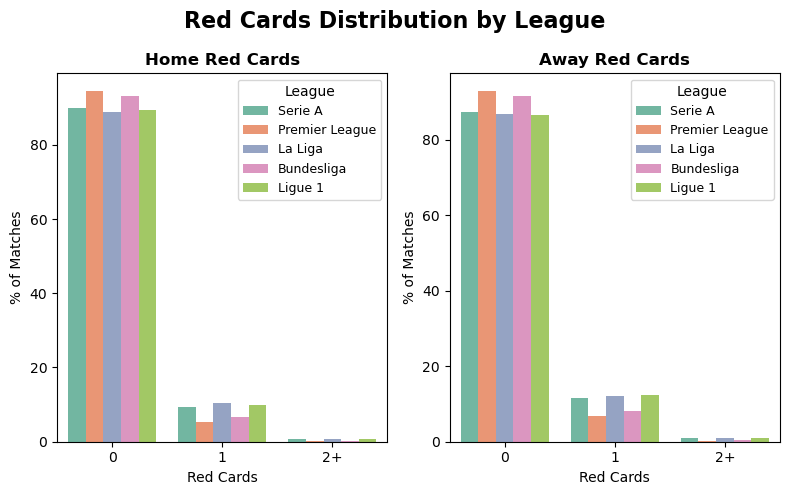

In [46]:
league_order = ['Serie A', 'Premier League', 'La Liga', 'Bundesliga', 'Ligue 1']
league_palette = dict(zip(league_order, sns.color_palette('Set2', len(league_order))))
card_order = ['0', '1', '2+']

red_card_cols = ['HR', 'AR']
col_labels_red = {'HR': 'Home Red Cards', 'AR': 'Away Red Cards'}

plot_data_red = pd.concat(
    [df[red_card_cols].assign(League=name) for name, df in league_dfs.items()],
    ignore_index=True
)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

for i, col in enumerate(red_card_cols):
    bucketed = (
        plot_data_red[['League', col]]
        .copy()
        .assign(**{col: plot_data_red[col].clip(upper=2).astype(int)})
    )
    counts = (
        bucketed.groupby(['League', col])
        .size()
        .reset_index(name='count')
    )
    counts['pct'] = counts.groupby('League')['count'].transform(lambda x: x / x.sum() * 100)
    counts[col] = counts[col].astype(str).replace({'2': '2+'})

    sns.barplot(data=counts, x=col, y='pct', hue='League',
                hue_order=league_order, order=card_order,
                palette=league_palette, ax=axes[i])
    axes[i].set_title(col_labels_red[col], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Red Cards')
    axes[i].set_ylabel('% of Matches')
    axes[i].legend(title='League', fontsize=9)

fig.suptitle('Red Cards Distribution by League', fontsize=16, fontweight='bold')
plt.tight_layout()

These two figures — the violin plot for fouls and yellow cards, and the bar chart for red cards — form a single coherent view of the discipline data. The choice to use different chart types for different variables is intentional and reflects the nature of the data, not an aesthetic preference.

Since this combination will be needed again in the analysis notebooks, it has been packaged into a reusable function `plot_discipline_distributions()` in `src/plots.py`. The function accepts the combined dataframe (with a `League` column), an optional league order, and a palette, and returns both figures. This notebook documents how and why the function was built; `src/plots.py` is the clean, importable result.

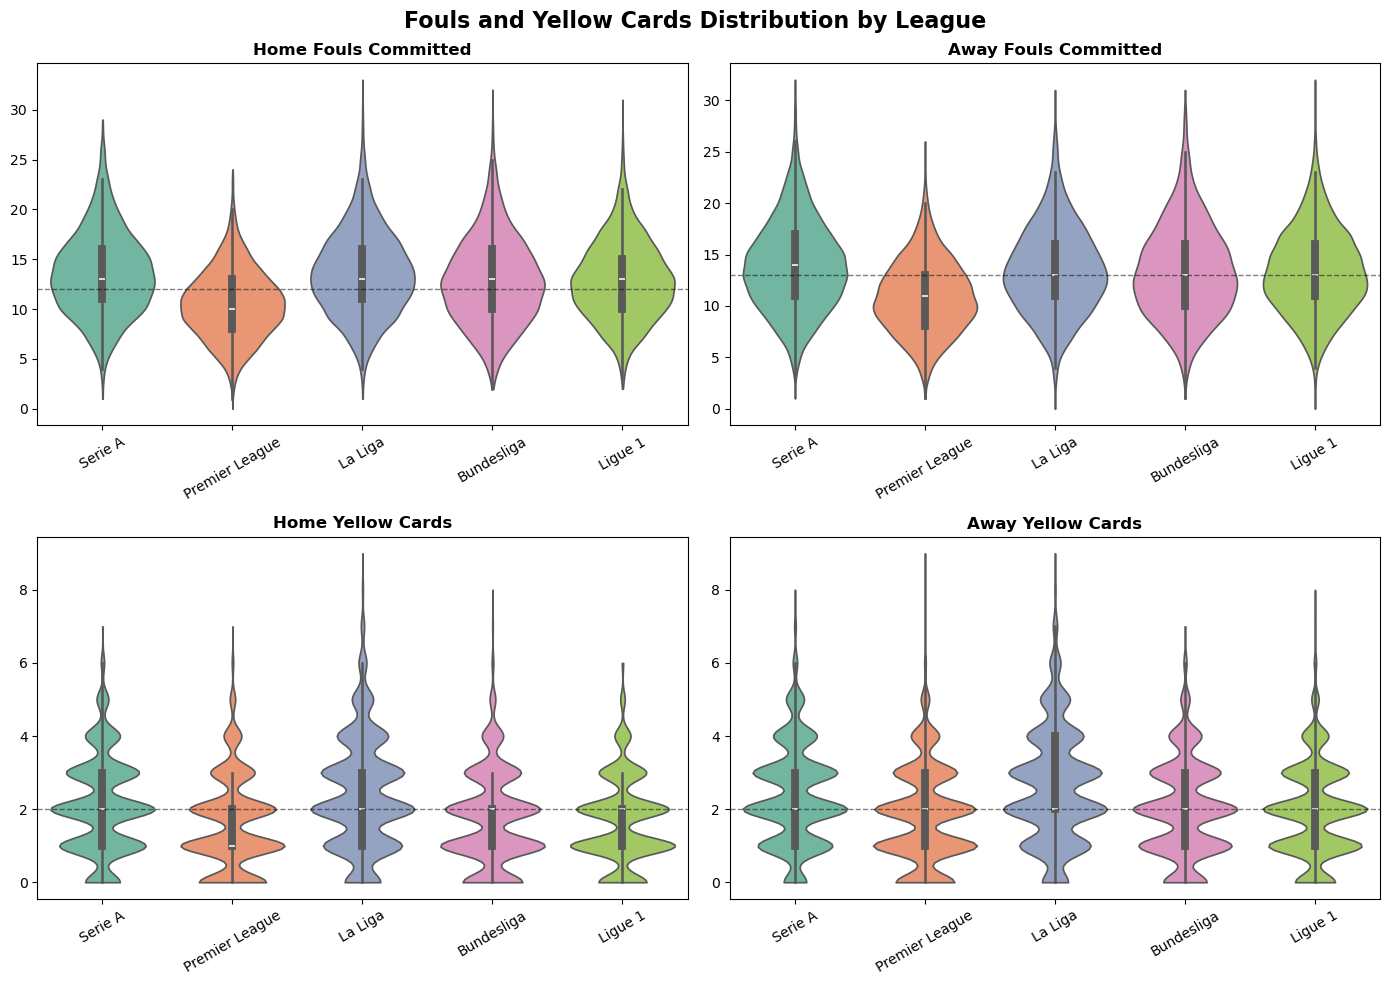

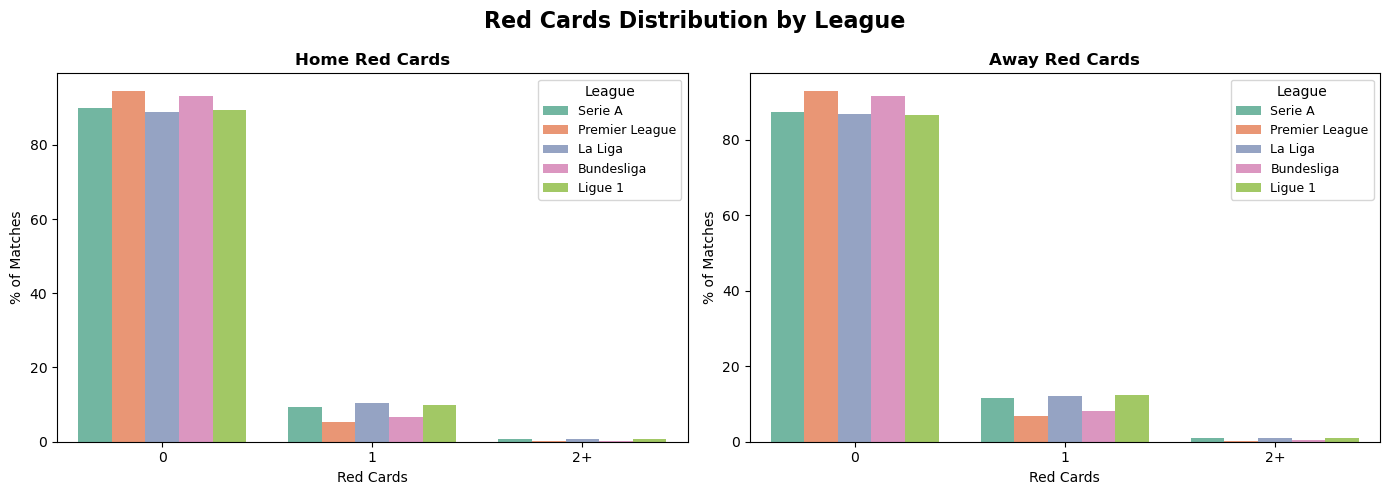

In [47]:
import sys
sys.path.append('../src')
from plots import plot_discipline_distributions

all_discipline_cols = ['HF', 'AF', 'HY', 'AY', 'HR', 'AR']
plot_data_full = pd.concat(
    [df[all_discipline_cols].assign(League=name) for name, df in league_dfs.items()],
    ignore_index=True
)

fig_violin, fig_bar = plot_discipline_distributions(plot_data_full, league_order=league_order)

The distributions across all five leagues are consistent with domain knowledge and show no signs of data collection errors: values are within plausible ranges, home/away patterns are symmetric, and the relative differences between leagues align with what is generally known about each competition's style of play.

One observation worth noting for the analysis ahead: the Premier League shows systematically lower fouls and red cards compared to other leagues. This is consistent with the commonly held view that English football allows a more physical style of play — whether this reflects a refereeing tendency to call fewer fouls, or an intrinsically different style of play, is something the data alone cannot resolve at this stage. It is, however, a pattern to keep in mind when interpreting cross-league comparisons.

Overall, at this stage there are no major data quality concerns. We can proceed to the wrangling phase with reasonable confidence in the data

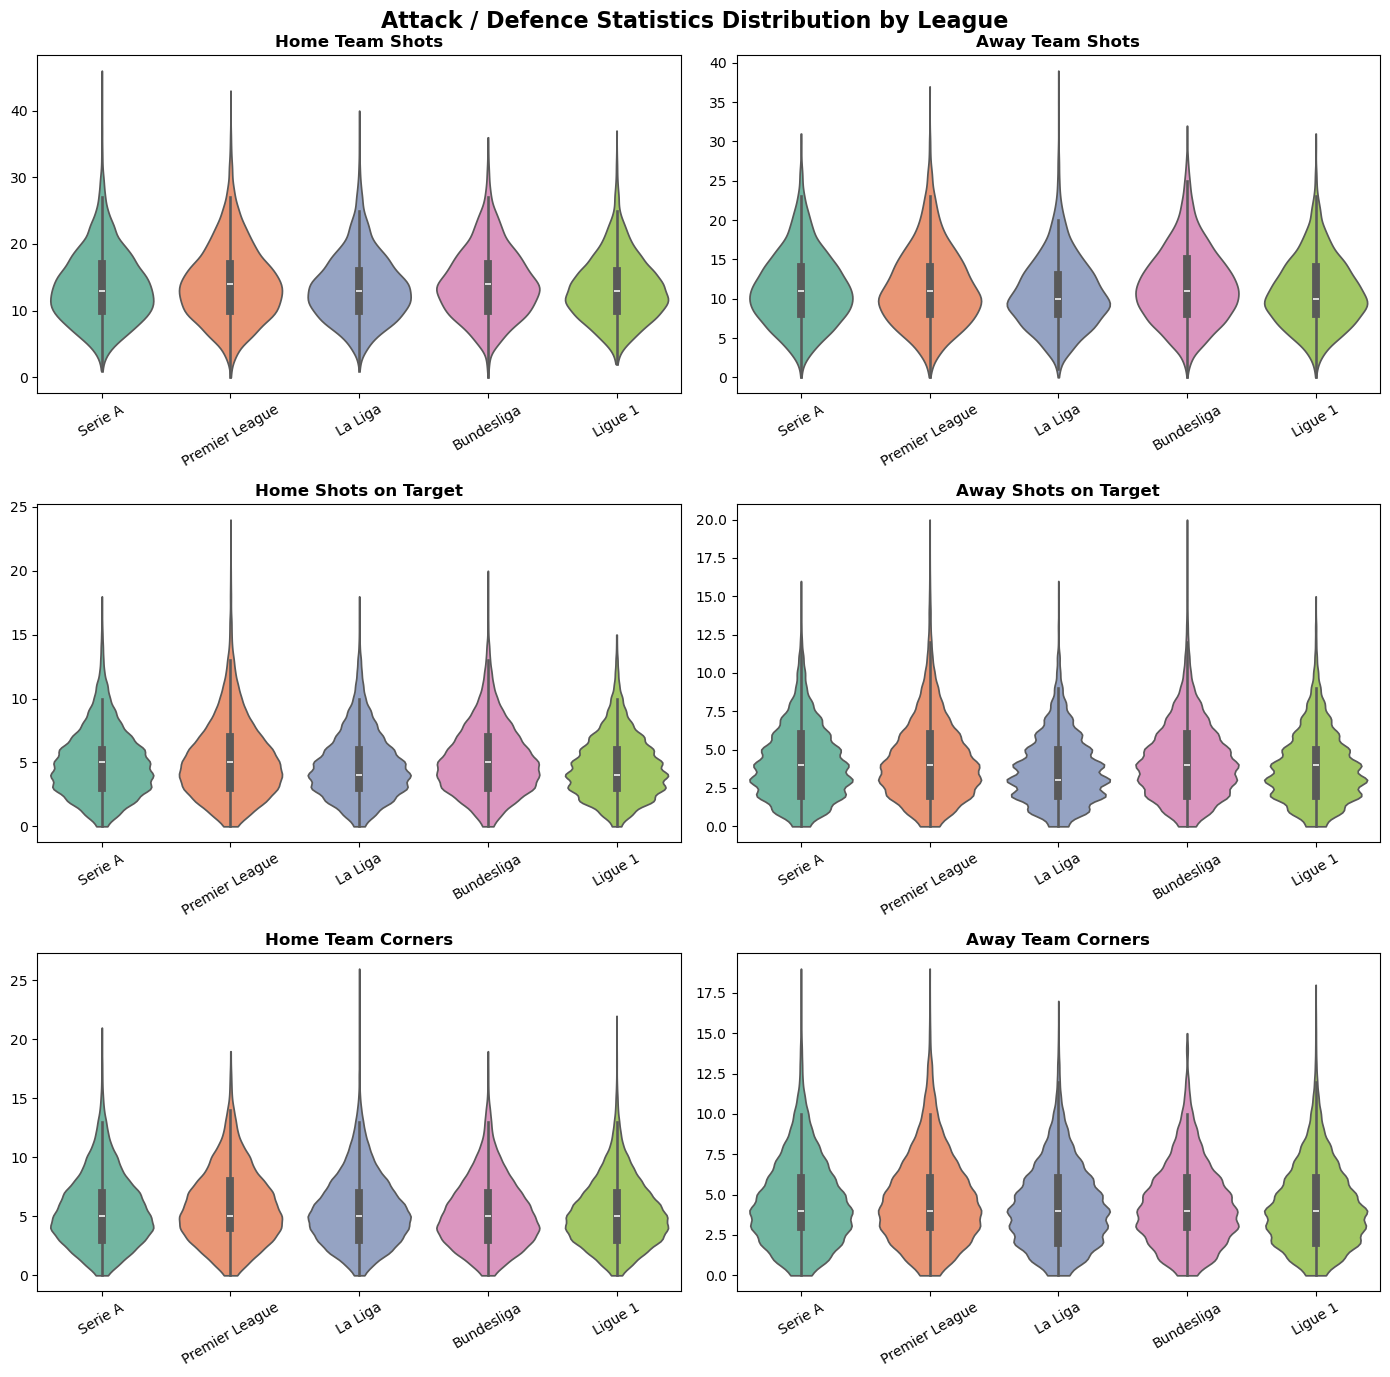

In [48]:
attack_defence_cols = ['HS', 'AS', 'HST', 'AST', 'HC', 'AC']

col_labels_atk = {
    'HS':  'Home Team Shots',
    'AS':  'Away Team Shots',
    'HST': 'Home Shots on Target',
    'AST': 'Away Shots on Target',
    'HC':  'Home Team Corners',
    'AC':  'Away Team Corners',
}

plot_data_atk = pd.concat(
    [df[attack_defence_cols].assign(League=name) for name, df in league_dfs.items()],
    ignore_index=True
)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(attack_defence_cols):
    sns.violinplot(
        data=plot_data_atk,
        x='League', y=col,
        hue='League',
        ax=axes[i],
        palette='Set2',
        legend=False,
        inner='box',
        cut=0,
    )
    axes[i].set_title(col_labels_atk[col], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Attack / Defence Statistics Distribution by League', fontsize=16, fontweight='bold')
plt.tight_layout()

The "trembling" violinplots we see on Home and Away Shots of target is due to the fact that both variables are integers and their unique values is expressed on a limited interval.

### Data Wrangling

In [49]:
def reshape_to_team_matches(df, league_name):
    home = df[[
        'season', 'Date', 'HomeTeam', 'AwayTeam',
        'HY', 'HR', 'HF', 'AF',
        'HS', 'AS', 'HST', 'AST', 'HC', 'AC',
        'FTHG', 'FTAG', 'FTR'
    ]].copy()
    home.columns = [
        'season', 'date', 'team', 'opponent',
        'yellow_cards', 'red_cards', 'fouls_committed', 'fouls_received',
        'shots', 'shots_opponent', 'shots_on_target', 'shots_on_target_opponent',
        'corners', 'corners_opponent',
        'goals_scored', 'goals_conceded', 'match_result'
    ]
    home['venue'] = 'home'
    home['team_result'] = home['match_result'].map({'H': 'W', 'D': 'D', 'A': 'L'})

    away = df[[
        'season', 'Date', 'AwayTeam', 'HomeTeam',
        'AY', 'AR', 'AF', 'HF',
        'AS', 'HS', 'AST', 'HST', 'AC', 'HC',
        'FTAG', 'FTHG', 'FTR'
    ]].copy()
    away.columns = [
        'season', 'date', 'team', 'opponent',
        'yellow_cards', 'red_cards', 'fouls_committed', 'fouls_received',
        'shots', 'shots_opponent', 'shots_on_target', 'shots_on_target_opponent',
        'corners', 'corners_opponent',
        'goals_scored', 'goals_conceded', 'match_result'
    ]
    away['venue'] = 'away'
    away['team_result'] = away['match_result'].map({'A': 'W', 'D': 'D', 'H': 'L'})

    return pd.concat([home, away], ignore_index=True).assign(league=league_name)


team_matches = pd.concat([
    reshape_to_team_matches(df, league)
    for league, df in leagues_data.items()
], ignore_index=True)


In [50]:
team_matches.head()

,season,date,team,opponent,yellow_cards,red_cards,fouls_committed,fouls_received,shots,shots_opponent,shots_on_target,shots_on_target_opponent,corners,corners_opponent,goals_scored,goals_conceded,match_result,venue,team_result,league
0,2526,23/08/2025,Genoa,Lecce,2.0,0.0,16.0,13.0,5.0,7.0,2.0,0.0,3.0,7.0,0.0,0.0,D,home,D,Serie_A
1,2526,23/08/2025,Sassuolo,Napoli,3.0,1.0,17.0,17.0,7.0,13.0,2.0,4.0,1.0,2.0,0.0,2.0,A,home,L,Serie_A
2,2526,23/08/2025,Milan,Cremonese,1.0,0.0,10.0,14.0,24.0,4.0,6.0,3.0,9.0,2.0,1.0,2.0,A,home,L,Serie_A
3,2526,23/08/2025,Roma,Bologna,1.0,0.0,15.0,13.0,14.0,10.0,4.0,2.0,2.0,4.0,1.0,0.0,H,home,W,Serie_A
4,2526,24/08/2025,Cagliari,Fiorentina,4.0,0.0,18.0,14.0,14.0,4.0,6.0,1.0,3.0,2.0,1.0,1.0,D,home,D,Serie_A


In [51]:
with open('../data/processed/team_matches.pkl', 'wb') as f:
    pickle.dump(team_matches, f)

---

> ***Below part is incomplete and is a draft. To be completed after analysing the data from National Leagues 

In [52]:
# Opening espn data

with open("../data/raw/espn_cards_data.pkl", "rb") as f:
    espn_data = pickle.load(f)

## International Competitions Data Dictionary

- `squad` - Team name
- `country_code` - Team country code  
- `num_pl` - number of players  
- `90s` - number of 90 minutes matches 
- `fls_committed` - number of fauls committed  
- `fld_drawn` - number of fauls received that lead to a shoot  
- `ycards_received` - number of yellow cards received  
- `rcards_received` - number of red cards received 
- `ycards_2nd_received` - number of second yellow cards received 
- `offsides_committed` - number of times the Team was on offside 
- `crosses_performed` - number of crosses performed 
- `interceptions_performed` - number of interceptions performed
- `tackles_won` - number of tackes won  
- `penalties_won` - number of penalties won  
- `og_scored` - number of own goal scored  
- `fls_won` - number of fauls drawn  
- `fld_conceded` - number of fauls committed that lead to a shoot 
- `ycards_caused` - number of yellow cards caused  
- `rcards_caused` - number of red cards caused 
- `ycards_2nd_caused` - number of second yellow cards caused
- `offsides_caused` - number of times the team succeed to offside the opponents  
- `crosses_faced` - number of crossed received 
- `interceptions_conceded` - number of interception conceded 
- `tackles_conceded` - number of tackles conceded 
- `penalties_conceded` - number of penalties conceded 
- `og_forced` - number of own goal forced  
- `competition` - competition name 
- `season` - season

In [53]:
european_comps_data.keys()

dict_keys(['UCL', 'UEL', 'UECL'])

### UCL data

In [54]:
UCL_data = european_comps_data['UCL']

#### Null Values

In [55]:
UCL_data.isna().sum()

squad                       0
country_code                0
num_pl                      0
90s                         0
fls_committed               0
fld_drawn                   0
ycards_received             0
rcards_received            32
ycards_2nd_received         0
offsides_committed          0
crosses_performed           0
interceptions_performed     0
tackles_won                 0
penalties_won              36
og_scored                   0
fls_won                     0
fld_conceded                0
ycards_caused               0
rcards_caused               0
ycards_2nd_caused           0
offsides_caused             0
crosses_faced               0
interceptions_conceded      0
tackles_conceded            0
penalties_conceded         36
og_forced                   0
competition                 0
season                      0
dtype: int64

In [56]:
UCL_data[UCL_data['rcards_received'].isna()].shape

(32, 28)

In [57]:
UCL_data['season'].value_counts().reset_index().sort_values(by='season').reset_index(drop=True)

,season,count
0,2016-2017,32
1,2017-2018,32
2,2018-2019,32
3,2019-2020,32
4,2020-2021,32
5,2021-2022,32
6,2022-2023,32
7,2023-2024,32
8,2024-2025,36
9,2025-2026,36


Beginning with the 2024–25 season, UEFA changed the format of their three club competitions, abandoning the group stage in favour of an expanded league phase. [The number of participating teams was increased from 32 to 36 teams.](https://en.wikipedia.org/wiki/UEFA_Champions_League#League_phase_and_knockout_phase)

In [58]:
UCL_data[UCL_data['rcards_received'].isna()].head()

,squad,country_code,num_pl,90s,fls_committed,fld_drawn,ycards_received,rcards_received,ycards_2nd_received,offsides_committed,...,rcards_caused,ycards_2nd_caused,offsides_caused,crosses_faced,interceptions_conceded,tackles_conceded,penalties_conceded,og_forced,competition,season
32,Anderlecht,be,20,6.0,69,58,6,NaN,0,17,...,0,0,12,86,73,69,1.0,1,UCL,2017-2018
33,APOEL FC,cy,21,6.0,63,67,13,NaN,0,20,...,0,0,12,151,73,69,0.0,0,UCL,2017-2018
34,Atlético Madrid,es,20,6.0,79,70,7,NaN,1,20,...,3,2,3,79,70,81,0.0,0,UCL,2017-2018
35,Barcelona,es,22,10.0,103,136,19,NaN,1,28,...,0,0,13,134,160,113,1.0,5,UCL,2017-2018
36,Basel,ch,21,8.0,99,80,14,NaN,0,26,...,1,0,13,128,93,76,0.0,0,UCL,2017-2018


In [59]:
pd.set_option('display.max_columns', None)
UCL_data[UCL_data['season'] == '2017-2018'].head(3)

,squad,country_code,num_pl,90s,fls_committed,fld_drawn,ycards_received,rcards_received,ycards_2nd_received,offsides_committed,crosses_performed,interceptions_performed,tackles_won,penalties_won,og_scored,fls_won,fld_conceded,ycards_caused,rcards_caused,ycards_2nd_caused,offsides_caused,crosses_faced,interceptions_conceded,tackles_conceded,penalties_conceded,og_forced,competition,season
32,Anderlecht,be,20,6.0,69,58,6,NaN,0,17,86,88,69,0.0,0,60,67,8,0,0,12,86,73,69,1.0,1,UCL,2017-2018
33,APOEL FC,cy,21,6.0,63,67,13,NaN,0,20,62,104,63,0.0,0,72,60,8,0,0,12,151,73,69,0.0,0,UCL,2017-2018
34,Atlético Madrid,es,20,6.0,79,70,7,NaN,1,20,117,90,80,1.0,1,73,75,10,3,2,3,79,70,81,0.0,0,UCL,2017-2018


In [60]:
UCL_data[UCL_data['penalties_won'].isna()]['season'].unique()

<StringArray>
['2025-2026']
Length: 1, dtype: str

Two issues should be addressed in order of priority:
- Season 2017/18 no data about red cards
- Season 2025/26 no data about penalties conceded

#### Duplicated

In [61]:
UCL_data.duplicated().sum()

np.int64(0)

### Europa League Data

In [62]:
UEL_data = european_comps_data['UEL']

In [63]:
UEL_data['season'].value_counts().reset_index().sort_values(by='season').reset_index(drop=True)

,season,count
0,2016-2017,56
1,2017-2018,56
2,2018-2019,56
3,2019-2020,56
4,2020-2021,56
5,2021-2022,40
6,2022-2023,40
7,2023-2024,40
8,2024-2025,36
9,2025-2026,36


#### Null data

In [64]:
UEL_data.isna().sum()

squad                       0
country_code                0
num_pl                      0
90s                         0
fls_committed               0
fld_drawn                   0
ycards_received             0
rcards_received            57
ycards_2nd_received         0
offsides_committed          0
crosses_performed           0
interceptions_performed     0
tackles_won                 0
penalties_won              36
og_scored                   0
fls_won                     0
fld_conceded                0
ycards_caused               0
rcards_caused               0
ycards_2nd_caused           0
offsides_caused             0
crosses_faced               0
interceptions_conceded      0
tackles_conceded            0
penalties_conceded         36
og_forced                   0
competition                 0
season                      0
dtype: int64

In [65]:
UEL_data[UEL_data['rcards_received'].isna()]['season'].value_counts()

season
2017-2018    56
2016-2017     1
Name: count, dtype: int64

Two issues should be addressed in order of priority:
- Season 2017/18 no data about red cards and one null value for season 2016/17
- Season 2025/26 no data about penalties conceded

#### Duplicated Values

In [66]:
UEL_data.duplicated().sum()

np.int64(0)

### Europa Conference League

In [67]:
european_comps_data.keys()

dict_keys(['UCL', 'UEL', 'UECL'])

In [68]:
UECL_data = european_comps_data['UECL']

In [69]:
UECL_data['season'].value_counts().reset_index().sort_values(by='season').reset_index(drop=True)

,season,count
0,2021-2022,40
1,2022-2023,40
2,2023-2024,40
3,2024-2025,36
4,2025-2026,36


#### Null Values

In [70]:
UECL_data.isna().sum()

squad                       0
country_code                0
num_pl                      0
90s                         0
fls_committed               0
fld_drawn                   0
ycards_received             0
rcards_received             0
ycards_2nd_received         0
offsides_committed          0
crosses_performed           0
interceptions_performed     0
tackles_won                 0
penalties_won              36
og_scored                   0
fls_won                     0
fld_conceded                0
ycards_caused               0
rcards_caused               0
ycards_2nd_caused           0
offsides_caused             0
crosses_faced               0
interceptions_conceded      0
tackles_conceded            0
penalties_conceded         36
og_forced                   0
competition                 0
season                      0
dtype: int64

In this case, we are just missing the information about penalties for the latest season.

#### Duplicated Values

In [71]:
UECL_data.duplicated().sum()

np.int64(0)

### International Competition - fill missing data

In [72]:
UCL_data.shape

(328, 28)

In [73]:
UCL_data_espn = espn_data['UCL']

In [74]:
UCL_data['season'].unique()

<StringArray>
['2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022',
 '2022-2023', '2023-2024', '2024-2025', '2025-2026']
Length: 10, dtype: str

In [75]:
UCL_data_espn['season'].unique()

<StringArray>
['2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022',
 '2022-2023', '2023-2024', '2024-2025', '2025-2026']
Length: 10, dtype: str

In [76]:
UCL_data['season'].value_counts().reset_index().sort_values(by='season')

,season,count
2,2016-2017,32
3,2017-2018,32
4,2018-2019,32
5,2019-2020,32
6,2020-2021,32
7,2021-2022,32
8,2022-2023,32
9,2023-2024,32
0,2024-2025,36
1,2025-2026,36


In [77]:
UCL_data_espn['season'].value_counts().reset_index().sort_values(by='season')

,season,count
0,2016-2017,50
1,2017-2018,50
2,2018-2019,50
3,2019-2020,50
6,2020-2021,32
7,2021-2022,32
8,2022-2023,32
9,2023-2024,32
4,2024-2025,36
5,2025-2026,36


In [78]:
UCL_data_espn[(UCL_data_espn['season'] == '2016-2017') & 
              (UCL_data_espn['yellow_cards'] != '-')].sort_values(by = 'team')['team'].values

<StringArray>
[               'AS Monaco',                  'Arsenal',
          'Atlético Madrid',                'Barcelona',
         'Bayer Leverkusen',            'Bayern Munich',
                  'Benfica',                 'Besiktas',
        'Borussia Dortmund', 'Borussia Mönchengladbach',
              'CSKA Moscow',                   'Celtic',
              'Club Brugge',            'Dinamo Zagreb',
              'Dynamo Kyiv',           'F.C. København',
                 'FC Basel',                 'FC Porto',
                 'Juventus',             'Legia Warsaw',
           'Leicester City',                     'Lyon',
          'Manchester City',                   'Napoli',
            'PSV Eindhoven',      'Paris Saint-Germain',
              'Real Madrid',                  'Sevilla',
              'Sporting CP',        'Tottenham Hotspur']
Length: 30, dtype: str

In [79]:
cols_test = ['squad', '90s', 'ycards_received' ,'rcards_received', 'ycards_2nd_received', 'ycards_caused', 'rcards_caused']
UCL_data[UCL_data['season'] == '2016-2017']['squad'].values

<StringArray>
[            'Arsenal',     'Atlético Madrid',           'Barcelona',
               'Basel',       'Bayern Munich',             'Benfica',
            'Beşiktaş',              'Celtic',         'Club Brugge',
         'CSKA Moscow',       'Dinamo Zagreb',            'Dortmund',
         'Dynamo Kyiv',       'FC Copenhagen',            'Gladbach',
            'Juventus',        'Legia Warsaw',      'Leicester City',
          'Leverkusen',  'Ludogorets Razgrad',                'Lyon',
     'Manchester City',              'Monaco',              'Napoli',
 'Paris Saint-Germain',               'Porto',                 'PSV',
         'Real Madrid',              'Rostov',             'Sevilla',
         'Sporting CP',   'Tottenham Hotspur']
Length: 32, dtype: str

In [81]:
print(UCL_data_espn.dtypes)
print(UCL_data_espn[UCL_data_espn['yellow_cards'] == '-'].shape)
print(UCL_data_espn[UCL_data_espn['yellow_cards'].isna()].shape)

team               str
games_played    object
yellow_cards    object
red_cards       object
season             str
competition        str
dtype: object
(82, 6)
(0, 6)


In [82]:
UCL_data_espn = UCL_data_espn[UCL_data_espn['yellow_cards'] != '-'].copy()

In [83]:
UCL_data_espn[UCL_data_espn['season'] == '2016-2017']

,team,games_played,yellow_cards,red_cards,season,competition
0,Juventus,13,27,2,2016-2017,UCL
1,AS Monaco,16,28,0,2016-2017,UCL
2,Barcelona,10,25,1,2016-2017,UCL
3,Bayern Munich,10,16,2,2016-2017,UCL
4,Atlético Madrid,12,21,0,2016-2017,UCL
5,FC Porto,10,15,2,2016-2017,UCL
6,Sevilla,8,15,2,2016-2017,UCL
7,Sporting CP,6,14,2,2016-2017,UCL
8,Manchester City,10,14,2,2016-2017,UCL
9,Besiktas,6,13,2,2016-2017,UCL


In [84]:
UCL_data['season'].value_counts().reset_index().sort_values(by='season')

,season,count
2,2016-2017,32
3,2017-2018,32
4,2018-2019,32
5,2019-2020,32
6,2020-2021,32
7,2021-2022,32
8,2022-2023,32
9,2023-2024,32
0,2024-2025,36
1,2025-2026,36


In [85]:
espn_data.keys()

dict_keys(['UCL', 'UEL'])

In [86]:
fbref_data = european_comps_data.copy()

for comp in ['UCL', 'UEL']:
    df = fbref_data[comp]
    missing = df[df['rcards_received'].isna()][['squad', 'season', 'rcards_received']]
    print(f"\n--- {comp} missing red cards ---")
    print(missing.to_string())


--- UCL missing red cards ---
                  squad     season  rcards_received
32           Anderlecht  2017-2018              NaN
33             APOEL FC  2017-2018              NaN
34      Atlético Madrid  2017-2018              NaN
35            Barcelona  2017-2018              NaN
36                Basel  2017-2018              NaN
37        Bayern Munich  2017-2018              NaN
38              Benfica  2017-2018              NaN
39             Beşiktaş  2017-2018              NaN
40               Celtic  2017-2018              NaN
41              Chelsea  2017-2018              NaN
42          CSKA Moscow  2017-2018              NaN
43             Dortmund  2017-2018              NaN
44            Feyenoord  2017-2018              NaN
45             Juventus  2017-2018              NaN
46            Liverpool  2017-2018              NaN
47      Manchester City  2017-2018              NaN
48       Manchester Utd  2017-2018              NaN
49               Monaco  2017-201

In [87]:
# ── Print ESPN team names for the seasons we need to fill ──
for comp in ['UCL', 'UEL']:
    for season in ['2017-2018', '2016-2017']:
        espn_teams = (
            espn_data[comp][espn_data[comp]['season'] == season]['team']
            .sort_values()
            .tolist()
        )
        print(f"\n📋 ESPN {comp} {season} teams:")
        print(espn_teams)


📋 ESPN UCL 2017-2018 teams:
['AEK Athens', 'AS Monaco', 'AS Roma', 'Ajax Amsterdam', 'Anderlecht', 'Apoel Nicosia', 'Atlético Madrid', 'BATE Borisov', 'Barcelona', 'Bayern Munich', 'Benfica', 'Besiktas', 'Borussia Dortmund', 'CSKA Moscow', 'Celtic', 'Chelsea', 'Club Brugge', 'Dynamo Kyiv', 'F.C. København', 'F91 Dudelange', 'FC Basel', 'FC Porto', 'FCSB', 'Feyenoord Rotterdam', 'Hibernians', 'Juventus', 'Legia Warsaw', 'Liverpool', 'MSK Zilina', 'Manchester City', 'Manchester United', 'NK Maribor', 'Napoli', 'Nice', 'Olympiacos', 'Paris Saint-Germain', 'Partizan Belgrade', 'Real Madrid', 'Rosenborg', 'Santa Coloma', 'Sevilla', 'Shakhtar Donetsk', 'Sheriff Tiraspol', 'Slavia Prague', 'Spartak Moscow', 'Sporting CP', 'The New Saints', 'Tottenham Hotspur', 'Vardar', 'Zalgiris Vilnius']

📋 ESPN UCL 2016-2017 teams:
['AS Monaco', 'AS Roma', 'Ajax Amsterdam', 'Anderlecht', 'Arsenal', 'Atlético Madrid', 'BATE Borisov', 'Barcelona', 'Bayer Leverkusen', 'Bayern Munich', 'Benfica', 'Besiktas', 

In [88]:
UCL_name_map = {
    # FBref name       : ESPN name
    "Anderlecht":           "Anderlecht",
    "APOEL FC":             "Apoel Nicosia",
    "Atlético Madrid":      "Atlético Madrid",
    "Barcelona":            "Barcelona",
    "Basel":                "FC Basel",
    "Bayern Munich":        "Bayern Munich",
    "Benfica":              "Benfica",
    "Beşiktaş":             "Besiktas",
    "Celtic":               "Celtic",
    "Chelsea":              "Chelsea",
    "CSKA Moscow":          "CSKA Moscow",
    "Dortmund":             "Borussia Dortmund",
    "Feyenoord":            "Feyenoord Rotterdam",
    "Juventus":             "Juventus",
    "Liverpool":            "Liverpool",
    "Manchester City":      "Manchester City",
    "Manchester Utd":       "Manchester United",
    "Monaco":               "AS Monaco",
    "Napoli":               "Napoli",
    "NK Maribor":           "NK Maribor",
    "Olympiacos":           "Olympiacos",
    "Paris Saint-Germain":  "Paris Saint-Germain",
    "Porto":                "FC Porto",
    "Qarabağ":              None,  # qualifying only — not in ESPN
    "RB Leipzig":           None,  # qualifying only — not in ESPN
    "Real Madrid":          "Real Madrid",
    "Roma":                 "AS Roma",
    "Sevilla":              "Sevilla",
    "Shakhtar Donetsk":     "Shakhtar Donetsk",
    "Spartak Moscow":       "Spartak Moscow",
    "Sporting CP":          "Sporting CP",
    "Tottenham Hotspur":    "Tottenham Hotspur",
}

UEL_name_map = {
    # 2016-2017
    "Saint-Étienne":        "Saint-Étienne",

    # 2017-2018
    "AEK Athens":           None,  # not in ESPN
    "Apollon Limassol":     "Apollon Limassol",
    "Arsenal":              "Arsenal",
    "Atalanta":             "Atalanta",
    "Athletic Club":        "Athletic Club",
    "Atlético Madrid":      None,  # not in ESPN
    "Austria Wien":         None,  # not in ESPN
    "Başakşehir":           None,  # not in ESPN
    "BATE Borisov":         "BATE Borisov",
    "Braga":                None,  # not in ESPN
    "Celtic":               "Celtic",
    "CSKA Moscow":          None,  # not in ESPN
    "Dortmund":             "Borussia Dortmund",
    "Dynamo Kyiv":          "Dynamo Kyiv",
    "Everton":              "Everton",
    "Fastav Zlín":          None,  # not in ESPN
    "FC Astana":            None,  # not in ESPN
    "FC Copenhagen":        None,  # not in ESPN
    "FC Sheriff Tiraspol":  None,  # not in ESPN
    "FCSB":                 "FCSB",
    "FK Vardar":            "Vardar",
    "Hapoel Be'er Sheva FC":None,  # not in ESPN
    "Hertha BSC":           "Hertha Berlin",
    "Hoffenheim":           None,  # not in ESPN
    "Köln":                 "FC Cologne",
    "Konyaspor":            None,  # not in ESPN
    "Lazio":                "Lazio",
    "Loko Moscow":          "Lokomotiv Moscow",
    "Ludogorets Razgrad":   None,  # not in ESPN
    "Lugano":               None,  # not in ESPN
    "Lyon":                 "Lyon",
    "Maccabi Tel Aviv FC":  "Maccabi Tel-Aviv",
    "Marseille":            "Marseille",
    "Milan":                "AC Milan",
    "Napoli":               "Napoli",
    "Nice":                 None,  # not in ESPN
    "Östersund":            None,  # not in ESPN
    "Partizan":             "Partizan Belgrade",
    "RB Leipzig":           None,  # not in ESPN
    "RB Salzburg":          None,  # not in ESPN
    "Real Sociedad":        "Real Sociedad",
    "Red Star":             None,  # not in ESPN
    "Rijeka":               None,  # not in ESPN
    "Rosenborg":            "Rosenborg",
    "Skënderbeu Korçë":     None,  # not in ESPN
    "Slavia Prague":        "Slavia Prague",
    "Spartak Moscow":       None,  # not in ESPN UEL
    "Sporting CP":          None,  # not in ESPN UEL
    "Viktoria Plzeň":       None,  # not in ESPN
    "Villarreal":           "Villarreal",
    "Vitesse":              "Vitesse",
    "Vitória Guimarães":    None,  # not in ESPN
    "Young Boys":           None,  # not in ESPN
    "Zenit":                None,  # not in ESPN
    "Zorya Luhansk":        None,  # not in ESPN
    "Zulte Waregem":        None,  # not in ESPN
}

In [89]:
def fill_red_cards(fbref_df, espn_df, name_map, seasons):
    fbref_df = fbref_df.copy()

    for season in seasons:
        espn_season = (
            espn_df[espn_df['season'] == season]
            .set_index('team')['red_cards']
        )
        mask = (fbref_df['season'] == season) & (fbref_df['rcards_received'].isna())

        for idx in fbref_df[mask].index:
            fbref_name = fbref_df.loc[idx, 'squad']
            espn_name  = name_map.get(fbref_name)

            if espn_name and espn_name in espn_season.index:
                fbref_df.loc[idx, 'rcards_received'] = espn_season[espn_name]
                print(f"  ✅ Filled: {fbref_name} → {espn_name} = {espn_season[espn_name]}")
            else:
                print(f"  ⚠️  No ESPN match: {fbref_name} — stays NaN")

    return fbref_df


# ── Apply ──
UCL_data = fill_red_cards(
    fbref_data['UCL'],
    espn_data['UCL'],
    UCL_name_map,
    seasons=['2017-2018']
)

UEL_data = fill_red_cards(
    fbref_data['UEL'],
    espn_data['UEL'],
    UEL_name_map,
    seasons=['2016-2017', '2017-2018']
)

  ✅ Filled: Anderlecht → Anderlecht = 1
  ✅ Filled: APOEL FC → Apoel Nicosia = 0
  ✅ Filled: Atlético Madrid → Atlético Madrid = 1
  ✅ Filled: Barcelona → Barcelona = 1
  ✅ Filled: Basel → FC Basel = 0
  ✅ Filled: Bayern Munich → Bayern Munich = 0
  ✅ Filled: Benfica → Benfica = 2
  ✅ Filled: Beşiktaş → Besiktas = 1
  ✅ Filled: Celtic → Celtic = 0
  ✅ Filled: Chelsea → Chelsea = 0
  ✅ Filled: CSKA Moscow → CSKA Moscow = 0
  ✅ Filled: Dortmund → Borussia Dortmund = 0
  ✅ Filled: Feyenoord → Feyenoord Rotterdam = 1
  ✅ Filled: Juventus → Juventus = 2
  ✅ Filled: Liverpool → Liverpool = 1
  ✅ Filled: Manchester City → Manchester City = 0
  ✅ Filled: Manchester Utd → Manchester United = 0
  ✅ Filled: Monaco → AS Monaco = 1
  ✅ Filled: Napoli → Napoli = 0
  ✅ Filled: NK Maribor → NK Maribor = 0
  ✅ Filled: Olympiacos → Olympiacos = 0
  ✅ Filled: Paris Saint-Germain → Paris Saint-Germain = 1
  ✅ Filled: Porto → FC Porto = 1
  ⚠️  No ESPN match: Qarabağ — stays NaN
  ⚠️  No ESPN match: RB Lei

In [90]:
# ── Document remaining NaN red cards ──
for comp, df in [('UCL', UCL_data), ('UEL', UEL_data)]:
    nan_rows = df[df['rcards_received'].isna()][['squad', 'season']]
    print(f"\n--- {comp} remaining NaN red cards: {len(nan_rows)} rows ---")
    print(nan_rows.to_string())



--- UCL remaining NaN red cards: 2 rows ---
         squad     season
55     Qarabağ  2017-2018
56  RB Leipzig  2017-2018

--- UEL remaining NaN red cards: 30 rows ---
                     squad     season
56              AEK Athens  2017-2018
61         Atlético Madrid  2017-2018
62            Austria Wien  2017-2018
63              Başakşehir  2017-2018
65                   Braga  2017-2018
67             CSKA Moscow  2017-2018
71             Fastav Zlín  2017-2018
72               FC Astana  2017-2018
73           FC Copenhagen  2017-2018
74     FC Sheriff Tiraspol  2017-2018
77   Hapoel Be'er Sheva FC  2017-2018
79              Hoffenheim  2017-2018
81               Konyaspor  2017-2018
84      Ludogorets Razgrad  2017-2018
85                  Lugano  2017-2018
91                    Nice  2017-2018
92               Östersund  2017-2018
94              RB Leipzig  2017-2018
95             RB Salzburg  2017-2018
97                Red Star  2017-2018
98                  Rijeka  2017-

---

⚠️ Known data gaps — `rcards_received`:
- UCL 2017-2018: Qarabağ, RB Leipzig (qualifying-only, no ESPN data)
- UEL 2017-2018: 28 teams (qualifying/group stage dropouts, no ESPN data)
- UEL 2016-2017: 0 remaining gaps

These rows are retained in the dataset but excluded from any 
red card analysis until a source is found.

In [91]:
df_Serie_A.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,AF,HY,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
0,23/08/2025,Genoa,Lecce,0.0,0.0,D,0.0,0.0,D,16.0,13.0,2.0,3.0,0.0,0.0,5.0,7.0,2.0,0.0,3.0,7.0,2526
1,23/08/2025,Sassuolo,Napoli,0.0,2.0,A,0.0,1.0,A,17.0,17.0,3.0,1.0,1.0,0.0,7.0,13.0,2.0,4.0,1.0,2.0,2526
2,23/08/2025,Milan,Cremonese,1.0,2.0,A,1.0,1.0,D,10.0,14.0,1.0,4.0,0.0,0.0,24.0,4.0,6.0,3.0,9.0,2.0,2526
3,23/08/2025,Roma,Bologna,1.0,0.0,H,0.0,0.0,D,15.0,13.0,1.0,1.0,0.0,0.0,14.0,10.0,4.0,2.0,2.0,4.0,2526
4,24/08/2025,Cagliari,Fiorentina,1.0,1.0,D,0.0,0.0,D,18.0,14.0,4.0,2.0,0.0,0.0,14.0,4.0,6.0,1.0,3.0,2.0,2526


In [92]:
def aggregate_league_data(df: pd.DataFrame, league_name: str) -> pd.DataFrame:
    """
    Aggregate match-level data to season/team level.
    Each team appears twice per match (home and away) — stack then aggregate.
    """

    # ── Home perspective ──
    home = df.rename(columns={
        'HomeTeam': 'team',  'AwayTeam': 'opponent',
        'FTHG': 'goals_scored',   'FTAG': 'goals_conceded',
        'HF':  'fouls_committed', 'AF':  'fouls_received',
        'HY':  'yellow_cards',    'AY':  'yellow_cards_opponent',
        'HR':  'red_cards',       'AR':  'red_cards_opponent',
        'HS':  'shots',           'AS':  'shots_opponent',
        'HST': 'shots_on_target', 'AST': 'shots_on_target_opponent',
        'HC':  'corners',         'AC':  'corners_opponent',
        'FTR': 'result_raw',
    }).copy()
    home['home_away'] = 'home'
    home['win']  = (home['result_raw'] == 'H').astype(int)
    home['draw'] = (home['result_raw'] == 'D').astype(int)
    home['loss'] = (home['result_raw'] == 'A').astype(int)

    # ── Away perspective ──
    away = df.rename(columns={
        'AwayTeam': 'team',  'HomeTeam': 'opponent',
        'FTAG': 'goals_scored',   'FTHG': 'goals_conceded',
        'AF':  'fouls_committed', 'HF':  'fouls_received',
        'AY':  'yellow_cards',    'HY':  'yellow_cards_opponent',
        'AR':  'red_cards',       'HR':  'red_cards_opponent',
        'AS':  'shots',           'HS':  'shots_opponent',
        'AST': 'shots_on_target', 'HST': 'shots_on_target_opponent',
        'AC':  'corners',         'HC':  'corners_opponent',
        'FTR': 'result_raw',
    }).copy()
    away['home_away'] = 'away'
    away['win']  = (away['result_raw'] == 'A').astype(int)
    away['draw'] = (away['result_raw'] == 'D').astype(int)
    away['loss'] = (away['result_raw'] == 'H').astype(int)

    # ── Stack home + away ──
    cols = [
        'season', 'team',
        'fouls_committed', 'fouls_received',
        'yellow_cards', 'red_cards',
        'goals_scored', 'goals_conceded',
        'shots', 'shots_on_target',
        'corners',
        'win', 'draw', 'loss'
    ]
    stacked = pd.concat([home[cols], away[cols]], ignore_index=True)

    # ── Aggregate per team/season ──
    agg = (
        stacked
        .groupby(['season', 'team'])
        .agg(
            matches          = ('win',              'count'),
            wins             = ('win',              'sum'),
            draws            = ('draw',             'sum'),
            losses           = ('loss',             'sum'),
            fouls_committed  = ('fouls_committed',  'sum'),
            fouls_received   = ('fouls_received',   'sum'),
            yellow_cards     = ('yellow_cards',     'sum'),
            red_cards        = ('red_cards',        'sum'),
            goals_scored     = ('goals_scored',     'sum'),
            goals_conceded   = ('goals_conceded',   'sum'),
            shots            = ('shots',            'sum'),
            shots_on_target  = ('shots_on_target',  'sum'),
            corners          = ('corners',          'sum'),
        )
        .reset_index()
    )

    # ── Derived metrics ──
    agg['points']              = agg['wins'] * 3 + agg['draws']
    agg['fouls_per_match']     = (agg['fouls_committed']  / agg['matches']).round(2)
    agg['yellows_per_match']   = (agg['yellow_cards']     / agg['matches']).round(2)
    agg['reds_per_match']      = (agg['red_cards']        / agg['matches']).round(2)
    agg['shots_per_match']     = (agg['shots']            / agg['matches']).round(2)
    agg['corners_per_match']   = (agg['corners']          / agg['matches']).round(2)
    agg['yellow_per_foul']     = (agg['yellow_cards']     / agg['fouls_committed']).round(4)
    agg['red_per_foul']        = (agg['red_cards']        / agg['fouls_committed']).round(4)

    agg['league'] = league_name
    return agg


# ── Apply to all leagues ──
all_data = leagues_data.copy()

LEAGUES = {
    'Serie_A':        all_data['Serie_A'],
    'Premier_League': all_data['Premier_League'],
    'La_Liga':        all_data['La_Liga'],
    'Bundesliga':        all_data['Bundesliga'],
    'Ligue_1' : all_data['Ligue_1']
}

league_agg = {
    name: aggregate_league_data(df, name)
    for name, df in LEAGUES.items()
}

# ── Combine all leagues ──
all_leagues = pd.concat(league_agg.values(), ignore_index=True)

# ── Preview ──
print(all_leagues.shape)
print(all_leagues.columns.tolist())
print(all_leagues.head(3))

(1464, 24)
['season', 'team', 'matches', 'wins', 'draws', 'losses', 'fouls_committed', 'fouls_received', 'yellow_cards', 'red_cards', 'goals_scored', 'goals_conceded', 'shots', 'shots_on_target', 'corners', 'points', 'fouls_per_match', 'yellows_per_match', 'reds_per_match', 'shots_per_match', 'corners_per_match', 'yellow_per_foul', 'red_per_foul', 'league']
  season      team  matches  wins  draws  losses  fouls_committed  \
0   1112  Atalanta       38    13     13      12            592.0   
1   1112   Bologna       38    13     12      13            638.0   
2   1112  Cagliari       38    10     13      15            613.0   

   fouls_received  yellow_cards  red_cards  goals_scored  goals_conceded  \
0           631.0          96.0        4.0          41.0            43.0   
1           705.0          96.0        3.0          41.0            43.0   
2           645.0          78.0        2.0          37.0            46.0   

   shots  shots_on_target  corners  points  fouls_per_matc

In [93]:
all_leagues[all_leagues['team'] == 'Atalanta']

,season,team,matches,wins,draws,losses,fouls_committed,fouls_received,yellow_cards,red_cards,goals_scored,goals_conceded,shots,shots_on_target,corners,points,fouls_per_match,yellows_per_match,reds_per_match,shots_per_match,corners_per_match,yellow_per_foul,red_per_foul,league
0,1112,Atalanta,38,13,13,12,592.0,631.0,96.0,4.0,41.0,43.0,413.0,142.0,189.0,52,15.58,2.53,0.11,10.87,4.97,0.1622,0.0068,Serie_A
20,1213,Atalanta,38,11,9,18,585.0,599.0,105.0,13.0,39.0,56.0,409.0,129.0,180.0,42,15.39,2.76,0.34,10.76,4.74,0.1795,0.0222,Serie_A
40,1314,Atalanta,38,15,5,18,525.0,564.0,81.0,6.0,43.0,51.0,447.0,154.0,190.0,50,13.82,2.13,0.16,11.76,5.00,0.1543,0.0114,Serie_A
60,1415,Atalanta,38,7,16,15,629.0,638.0,103.0,9.0,38.0,57.0,463.0,132.0,193.0,37,16.55,2.71,0.24,12.18,5.08,0.1638,0.0143,Serie_A
80,1516,Atalanta,38,11,12,15,636.0,618.0,95.0,14.0,41.0,47.0,454.0,137.0,190.0,45,16.74,2.50,0.37,11.95,5.00,0.1494,0.0220,Serie_A
100,1617,Atalanta,38,21,9,8,603.0,568.0,85.0,3.0,62.0,41.0,534.0,201.0,229.0,72,15.87,2.24,0.08,14.05,6.03,0.1410,0.0050,Serie_A
120,1718,Atalanta,38,16,12,10,491.0,499.0,67.0,4.0,57.0,39.0,573.0,197.0,229.0,60,12.92,1.76,0.11,15.08,6.03,0.1365,0.0081,Serie_A
140,1819,Atalanta,38,20,9,9,429.0,507.0,61.0,3.0,77.0,46.0,475.0,254.0,242.0,69,11.29,1.61,0.08,12.50,6.37,0.1422,0.0070,Serie_A
160,1920,Atalanta,38,23,9,6,528.0,548.0,80.0,2.0,98.0,48.0,540.0,312.0,248.0,78,13.89,2.11,0.05,14.21,6.53,0.1515,0.0038,Serie_A
180,2021,Atalanta,38,23,9,6,581.0,500.0,67.0,3.0,90.0,47.0,551.0,277.0,201.0,78,15.29,1.76,0.08,14.50,5.29,0.1153,0.0052,Serie_A


In [94]:
UCL_data['season']

0      2016-2017
1      2016-2017
2      2016-2017
3      2016-2017
4      2016-2017
         ...    
323    2025-2026
324    2025-2026
325    2025-2026
326    2025-2026
327    2025-2026
Name: season, Length: 328, dtype: str

---

# TO DELETE

In [95]:
def aggregate_league_data(df: pd.DataFrame, league_name: str) -> pd.DataFrame:

    # ── Home perspective ──
    home = df.rename(columns={
        'HomeTeam': 'team',       'AwayTeam': 'opponent',
        'FTHG': 'goals_scored',   'FTAG': 'goals_conceded',
        'HF':  'fouls_committed', 'AF':  'fouls_received',
        'HY':  'yellow_cards',    'AY':  'yellow_cards_forced',
        'HR':  'red_cards',       'AR':  'red_cards_forced',
        'HS':  'shots',           'AS':  'shots_opponent',
        'HST': 'shots_on_target', 'AST': 'shots_on_target_opponent',
        'HC':  'corners',         'AC':  'corners_opponent',
        'FTR': 'result_raw',
    }).copy()
    home['win']  = (home['result_raw'] == 'H').astype(int)
    home['draw'] = (home['result_raw'] == 'D').astype(int)
    home['loss'] = (home['result_raw'] == 'A').astype(int)

    # ── Away perspective ──
    away = df.rename(columns={
        'AwayTeam': 'team',       'HomeTeam': 'opponent',
        'FTAG': 'goals_scored',   'FTHG': 'goals_conceded',
        'AF':  'fouls_committed', 'HF':  'fouls_received',
        'AY':  'yellow_cards',    'HY':  'yellow_cards_forced',
        'AR':  'red_cards',       'HR':  'red_cards_forced',
        'AS':  'shots',           'HS':  'shots_opponent',
        'AST': 'shots_on_target', 'HST': 'shots_on_target_opponent',
        'AC':  'corners',         'HC':  'corners_opponent',
        'FTR': 'result_raw',
    }).copy()
    away['win']  = (away['result_raw'] == 'A').astype(int)
    away['draw'] = (away['result_raw'] == 'D').astype(int)
    away['loss'] = (away['result_raw'] == 'H').astype(int)

    # ── Stack ──
    cols = [
        'season', 'team',
        'fouls_committed', 'fouls_received',
        'yellow_cards',    'yellow_cards_forced',
        'red_cards',       'red_cards_forced',
        'goals_scored',    'goals_conceded',
        'shots',           'shots_on_target',
        'corners',         'win', 'draw', 'loss'
    ]
    stacked = pd.concat([home[cols], away[cols]], ignore_index=True)

    # ── Aggregate ──
    agg = (
        stacked
        .groupby(['season', 'team'])
        .agg(
            matches              = ('win',                 'count'),
            wins                 = ('win',                 'sum'),
            draws                = ('draw',                'sum'),
            losses               = ('loss',                'sum'),
            fouls_committed      = ('fouls_committed',     'sum'),
            fouls_received       = ('fouls_received',      'sum'),
            yellow_cards         = ('yellow_cards',        'sum'),
            yellow_cards_forced  = ('yellow_cards_forced', 'sum'),
            red_cards            = ('red_cards',           'sum'),
            red_cards_forced     = ('red_cards_forced',    'sum'),
            goals_scored         = ('goals_scored',        'sum'),
            goals_conceded       = ('goals_conceded',      'sum'),
            shots                = ('shots',               'sum'),
            shots_on_target      = ('shots_on_target',     'sum'),
            corners              = ('corners',             'sum'),
        )
        .reset_index()
    )

    # ── Per match rates ──
    agg['points']                    = agg['wins'] * 3 + agg['draws']
    agg['fouls_committed_per_match'] = (agg['fouls_committed']     / agg['matches']).round(2)
    agg['fouls_received_per_match']  = (agg['fouls_received']      / agg['matches']).round(2)
    agg['yellows_per_match']         = (agg['yellow_cards']        / agg['matches']).round(2)
    agg['reds_per_match']            = (agg['red_cards']           / agg['matches']).round(2)
    agg['shots_per_match']           = (agg['shots']               / agg['matches']).round(2)
    agg['corners_per_match']         = (agg['corners']             / agg['matches']).round(2)

    # ── Card rate per foul ──
    agg['yellow_per_foul_committed'] = (agg['yellow_cards']        / agg['fouls_committed']).round(4)
    agg['yellow_per_foul_received']  = (agg['yellow_cards_forced'] / agg['fouls_received']).round(4)
    agg['red_per_foul_committed']    = (agg['red_cards']           / agg['fouls_committed']).round(4)
    agg['red_per_foul_received']     = (agg['red_cards_forced']    / agg['fouls_received']).round(4)

    # ── Symmetry ratios ──
    agg['yellow_symmetry_ratio']     = (agg['yellow_per_foul_committed'] / agg['yellow_per_foul_received']).round(4)
    agg['red_symmetry_ratio']        = (agg['red_per_foul_committed']    / agg['red_per_foul_received']).round(4)

    # ── Stage 1 prep ──
    agg['yellow_symmetry_dev']       = (agg['yellow_symmetry_ratio'] - 1.0).round(4)
    agg['red_symmetry_dev']          = (agg['red_symmetry_ratio']    - 1.0).round(4)
    agg['yellow_symmetry_abs_dev']   = agg['yellow_symmetry_dev'].abs().round(4)
    agg['red_symmetry_abs_dev']      = agg['red_symmetry_dev'].abs().round(4)
    agg['yellow_symmetry_direction'] = agg['yellow_symmetry_dev'].apply(
        lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
    )
    agg['red_symmetry_direction']    = agg['red_symmetry_dev'].apply(
        lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
    )
    agg['yellow_card_imbalance']     = agg['yellow_cards'] - agg['yellow_cards_forced']
    agg['red_card_imbalance']        = agg['red_cards']    - agg['red_cards_forced']

    agg['league'] = league_name
    return agg

In [96]:
LEAGUES = {
    'Serie_A':        all_data['Serie_A'],
    # 'Premier_League': all_data['Premier_League'],
    # 'La_Liga':        all_data['La_Liga'],
}

league_agg = {
    name: aggregate_league_data(df, name)
    for name, df in LEAGUES.items()
}

all_leagues = pd.concat(league_agg.values(), ignore_index=True)

print(f"Shape: {all_leagues.shape}")
print(f"Leagues: {all_leagues['league'].unique()}")
print(f"Seasons: {sorted(all_leagues['season'].unique())}")
print(all_leagues.head(3))

Shape: (300, 39)
Leagues: <StringArray>
['Serie_A']
Length: 1, dtype: str
Seasons: ['1112', '1213', '1314', '1415', '1516', '1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425', '2526']
  season      team  matches  wins  draws  losses  fouls_committed  \
0   1112  Atalanta       38    13     13      12            592.0   
1   1112   Bologna       38    13     12      13            638.0   
2   1112  Cagliari       38    10     13      15            613.0   

   fouls_received  yellow_cards  yellow_cards_forced  red_cards  \
0           631.0          96.0                 72.0        4.0   
1           705.0          96.0                 98.0        3.0   
2           645.0          78.0                 90.0        2.0   

   red_cards_forced  goals_scored  goals_conceded  shots  shots_on_target  \
0               8.0          41.0            43.0  413.0            142.0   
1              11.0          41.0            43.0  444.0            155.0   
2               4.0

In [97]:
all_leagues.columns

Index(['season', 'team', 'matches', 'wins', 'draws', 'losses',
       'fouls_committed', 'fouls_received', 'yellow_cards',
       'yellow_cards_forced', 'red_cards', 'red_cards_forced', 'goals_scored',
       'goals_conceded', 'shots', 'shots_on_target', 'corners', 'points',
       'fouls_committed_per_match', 'fouls_received_per_match',
       'yellows_per_match', 'reds_per_match', 'shots_per_match',
       'corners_per_match', 'yellow_per_foul_committed',
       'yellow_per_foul_received', 'red_per_foul_committed',
       'red_per_foul_received', 'yellow_symmetry_ratio', 'red_symmetry_ratio',
       'yellow_symmetry_dev', 'red_symmetry_dev', 'yellow_symmetry_abs_dev',
       'red_symmetry_abs_dev', 'yellow_symmetry_direction',
       'red_symmetry_direction', 'yellow_card_imbalance', 'red_card_imbalance',
       'league'],
      dtype='str')

In [98]:
teams = ['Inter', 'Napoli', 'Juventus']

test1 = all_leagues[all_leagues['team'].isin(teams)][['team', 
                                              'season',
                                              'yellow_per_foul_committed', 
                                              'yellow_per_foul_received',
                                              'yellow_symmetry_ratio'
                                              ]].sort_values(by=['team', 'season'])

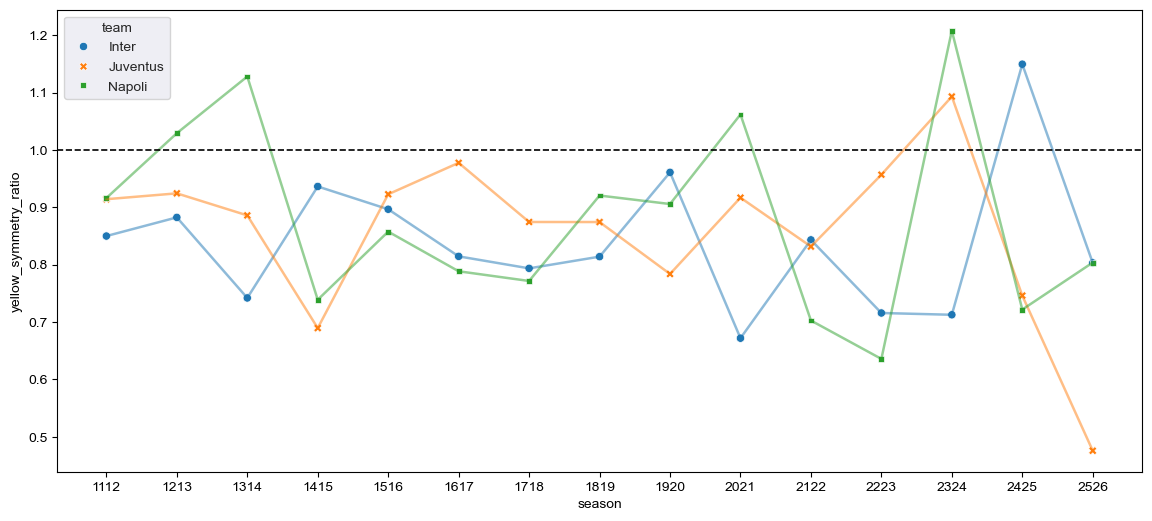

In [99]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.set_style("darkgrid")
sns.scatterplot(
    data=test1,
    x='season',
    y='yellow_symmetry_ratio',
    hue='team',
    style='team',
    ax=ax
)
for team, group in test1.groupby('team'):
    ax.plot(group['season'], group['yellow_symmetry_ratio'], linewidth=1.8, alpha=0.5)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2)


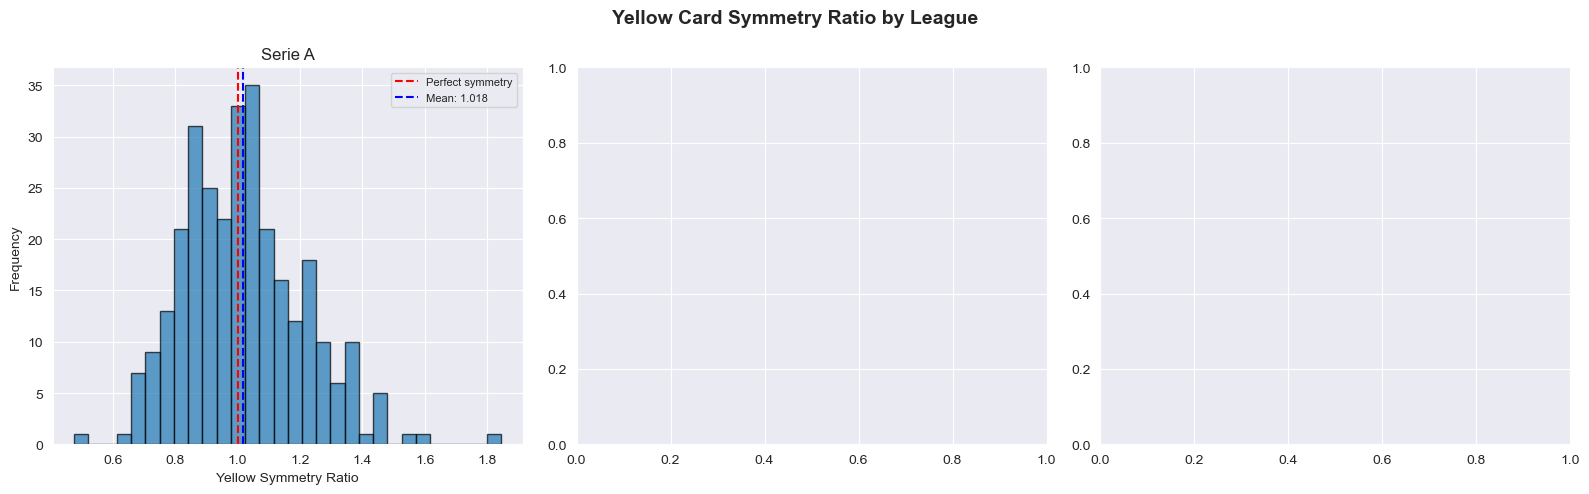

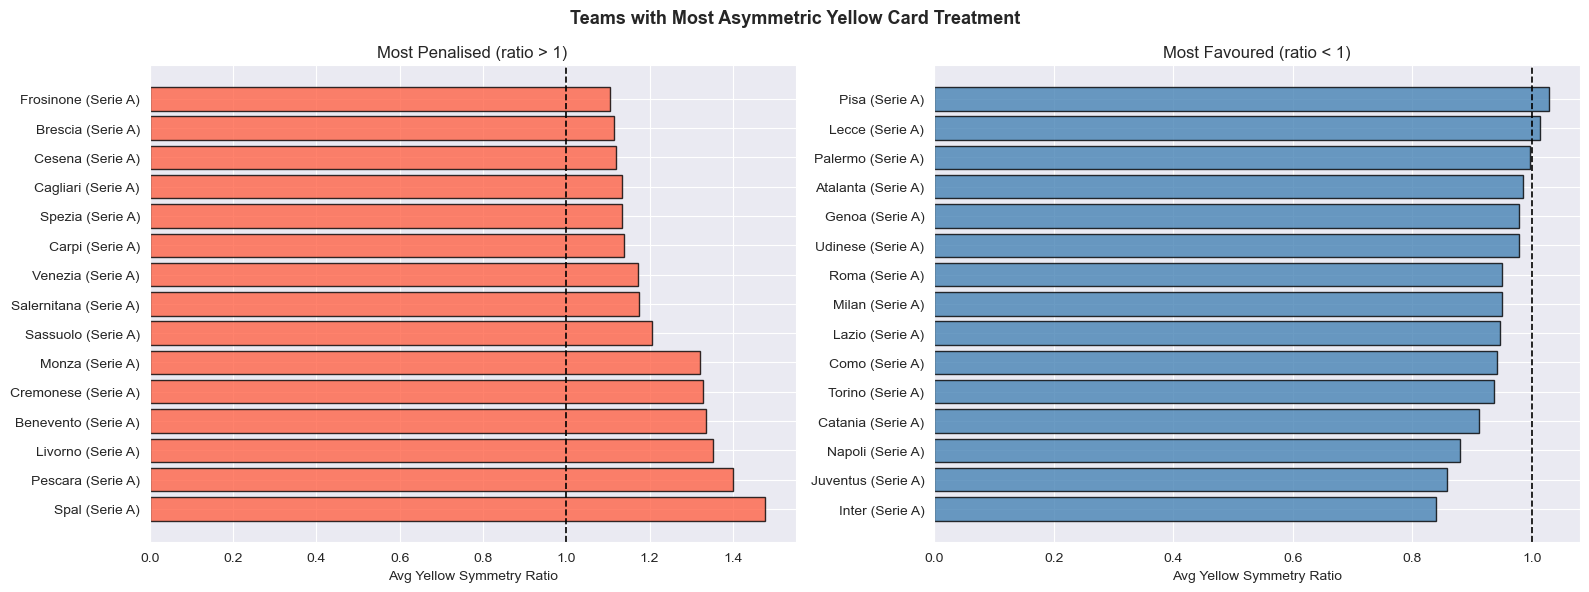

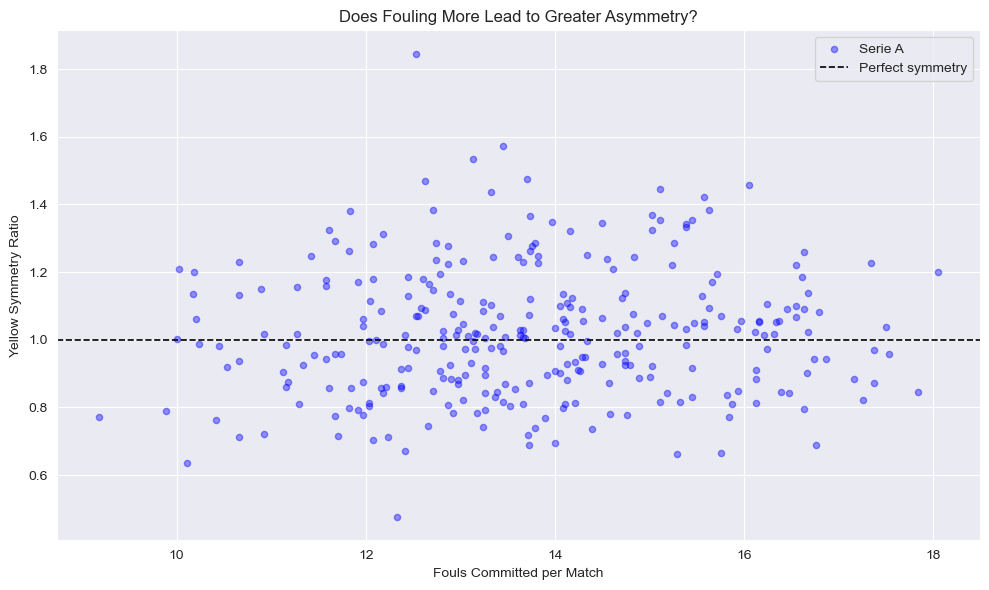

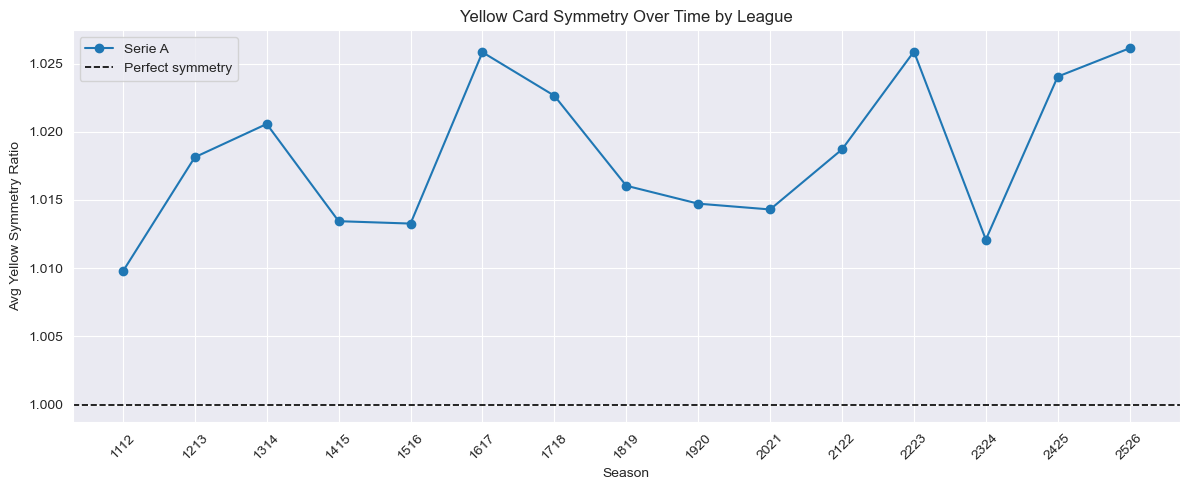

In [100]:
# ── Plot 1: Distribution of yellow symmetry ratio ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Yellow Card Symmetry Ratio by League", fontsize=14, fontweight='bold')

for ax, (league, group) in zip(axes, all_leagues.groupby('league')):
    ax.hist(group['yellow_symmetry_ratio'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Perfect symmetry')
    ax.axvline(group['yellow_symmetry_ratio'].mean(), color='blue', linestyle='--',
               linewidth=1.5, label=f"Mean: {group['yellow_symmetry_ratio'].mean():.3f}")
    ax.set_title(league.replace('_', ' '))
    ax.set_xlabel('Yellow Symmetry Ratio')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 2: Top 15 most asymmetric teams ──
team_avg = (
    all_leagues
    .groupby(['team', 'league'])
    .agg(
        avg_yellow_symmetry = ('yellow_symmetry_ratio', 'mean'),
        avg_red_symmetry    = ('red_symmetry_ratio',    'mean'),
        seasons             = ('season',                'count')
    )
    .reset_index()
    .dropna(subset=['avg_yellow_symmetry'])
)

top_penalised = team_avg.nlargest(15,  'avg_yellow_symmetry')
top_favoured  = team_avg.nsmallest(15, 'avg_yellow_symmetry')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Teams with Most Asymmetric Yellow Card Treatment", fontsize=13, fontweight='bold')

axes[0].barh(
    top_penalised['team'] + ' (' + top_penalised['league'].str.replace('_', ' ') + ')',
    top_penalised['avg_yellow_symmetry'],
    color='tomato', edgecolor='black', alpha=0.8
)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.2)
axes[0].set_title('Most Penalised (ratio > 1)')
axes[0].set_xlabel('Avg Yellow Symmetry Ratio')

axes[1].barh(
    top_favoured['team'] + ' (' + top_favoured['league'].str.replace('_', ' ') + ')',
    top_favoured['avg_yellow_symmetry'],
    color='steelblue', edgecolor='black', alpha=0.8
)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title('Most Favoured (ratio < 1)')
axes[1].set_xlabel('Avg Yellow Symmetry Ratio')
plt.tight_layout()
plt.show()

# ── Plot 3: Fouls committed vs yellow symmetry ratio ──
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Serie_A': 'blue', 'Premier_League': 'red', 'La_Liga': 'green'}

for league, group in all_leagues.groupby('league'):
    ax.scatter(
        group['fouls_committed_per_match'],
        group['yellow_symmetry_ratio'],
        alpha=0.4, s=20,
        color=colors[league],
        label=league.replace('_', ' ')
    )

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Perfect symmetry')
ax.set_xlabel('Fouls Committed per Match')
ax.set_ylabel('Yellow Symmetry Ratio')
ax.set_title('Does Fouling More Lead to Greater Asymmetry?')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 4: Symmetry over time ──
time_avg = (
    all_leagues
    .groupby(['season', 'league'])['yellow_symmetry_ratio']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for league, group in time_avg.groupby('league'):
    ax.plot(group['season'], group['yellow_symmetry_ratio'],
            marker='o', label=league.replace('_', ' '))

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Perfect symmetry')
ax.set_xlabel('Season')
ax.set_ylabel('Avg Yellow Symmetry Ratio')
ax.set_title('Yellow Card Symmetry Over Time by League')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()